# EDA — OP_AURUM_extract.csv

Analisis exploratorio del extracto de telemetria OPUS-MINE de la Unidad Minera La Cornisa.
El notebook recorre **una variable por seccion**, en el orden en que se entienden y no en el
del archivo: primero el tiempo y la ubicacion, luego la ley y lo que se deriva de ella,
despues los sensores de perforacion y por ultimo las fallas y los actores. Cada seccion
describe la variable, la contrasta con lo que dice el diccionario y deja constancia de donde
el dato lo contradice.

El diccionario de variables y el analisis conceptual estan en `docs/diccionario_variables.md`.

**Ejecucion.** El CSV no se versiona en el repositorio. El notebook lo busca en la variable
de entorno `AURUM_CSV_PATH` y, si no esta definida, en el directorio `insumos/` hermano del
repositorio.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paleta y estilo. Roles semanticos, no valores sueltos repartidos por el notebook.
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]
CRITICAL = "#d03b3b"

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 9,
    "figure.dpi": 110,
    "legend.frameon": False,
})

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


def locate_csv() -> Path:
    env = os.environ.get("AURUM_CSV_PATH")
    if env:
        return Path(env).expanduser().resolve()
    here = Path.cwd().resolve()
    for parent in [here, *here.parents]:
        candidate = parent / "insumos" / "OP_AURUM_extract.csv"
        if candidate.exists():
            return candidate
        candidate = parent.parent / "insumos" / "OP_AURUM_extract.csv"
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Define AURUM_CSV_PATH con la ruta a OP_AURUM_extract.csv")


CSV_PATH = locate_csv()
df = pd.read_csv(CSV_PATH, parse_dates=["ts_opus_utc"])
print(f"origen : {CSV_PATH.name}")
print(f"filas  : {len(df):,}")
print(f"columnas: {df.shape[1]}")

BOX_STYLE = {
    "vert": False,
    "widths": 0.55,
    "patch_artist": True,
    "boxprops": {"facecolor": SERIES[0], "alpha": 0.25, "edgecolor": INK, "linewidth": 1},
    "medianprops": {"color": CRITICAL, "linewidth": 2},
    "whiskerprops": {"color": INK, "linewidth": 1},
    "capprops": {"color": INK, "linewidth": 1},
    "flierprops": {"marker": ".", "markersize": 3, "markerfacecolor": MUTED,
                   "markeredgecolor": "none", "alpha": 0.35},
}


def hist_box(serie, titulo, xlabel, lo=None, hi=None, bins=50):
    """Histograma y diagrama de caja de una variable numerica, con los limites del diccionario."""
    fig, axes = plt.subplots(2, 1, figsize=(6.6, 3.6), sharex=True,
                             gridspec_kw={"height_ratios": [3, 1], "hspace": 0.12})
    axes[0].hist(serie.dropna(), bins=bins, color=SERIES[0], edgecolor=SURFACE, linewidth=0.4)
    axes[0].set_ylabel("registros")
    axes[0].set_title(titulo)
    axes[0].grid(axis="y")
    axes[0].set_axisbelow(True)

    axes[1].boxplot(serie.dropna(), **BOX_STYLE)
    axes[1].set_yticks([])
    axes[1].set_xlabel(xlabel)
    axes[1].grid(axis="x")
    axes[1].set_axisbelow(True)

    for ax in axes:
        for limite in (lo, hi):
            if limite is not None:
                ax.axvline(limite, color=CRITICAL, linewidth=1.5, linestyle="--")
    plt.tight_layout()
    plt.show()


def perfil_sensor(col, lo=None, hi=None, bins=50):
    """Distribucion de un sensor, su relacion con los limites del diccionario y con la ley."""
    serie = df[col]
    print(serie.describe().round(2).to_string())
    print()
    print(f"correlacion con ley_au_gpT: {valida[col].corr(valida['ley_au_gpT']):+.4f}")
    if lo is not None or hi is not None:
        fuera = pd.Series(False, index=df.index)
        if lo is not None:
            fuera |= serie < lo
        if hi is not None:
            fuera |= serie > hi
        print(f"fuera de limite           : {int(fuera.sum())} registros ({fuera.mean() * 100:.2f}%)")
        print(f"tasa de falla fuera       : {df.loc[fuera, 'falla'].mean() * 100:.2f}%"
              if fuera.any() else "tasa de falla fuera       : sin registros fuera de limite")
        print(f"tasa de falla dentro      : {df.loc[~fuera, 'falla'].mean() * 100:.2f}%")
    hist_box(serie, f"Distribucion de {col}", col, lo=lo, hi=hi, bins=bins)


def perfil_categorica(col, valor="ley_au_gpT"):
    """Frecuencia de una categorica, ley media y tasa de falla; barras de conteo y caja de la ley."""
    tabla = pd.DataFrame({
        "registros": df[col].value_counts(),
        "ley_media": valida.groupby(col)[valor].mean().round(2),
        "falla_pct": (df.groupby(col)["falla"].mean() * 100).round(2),
    }).sort_values("registros", ascending=False)

    orden = tabla.index.tolist()[::-1]
    alto = max(2.6, 0.34 * len(orden) + 1.1)
    fig, axes = plt.subplots(1, 2, figsize=(11, alto))

    axes[0].barh([str(k) for k in orden], tabla["registros"].reindex(orden).values,
                 color=SERIES[0], height=0.6)
    axes[0].set_title(f"Registros por {col}")
    axes[0].set_xlabel("registros")
    axes[0].grid(axis="x")
    axes[0].set_axisbelow(True)

    axes[1].boxplot([valida.loc[valida[col] == k, valor].dropna().values for k in orden],
                    tick_labels=[str(k) for k in orden], **BOX_STYLE)
    axes[1].set_title(f"{valor} por {col}")
    axes[1].set_xlabel(valor)
    axes[1].grid(axis="x")
    axes[1].set_axisbelow(True)

    plt.tight_layout()
    plt.show()
    return tabla

origen : OP_AURUM_extract.csv
filas  : 50,000
columnas: 18


## 1. El extracto completo: forma, tipos y completitud

Antes de mirar variable por variable: que hay, que falta y bajo que forma. La distincion
importante es entre el faltante declarado (`NaN`) y el faltante codificado dentro del dominio
numerico, que ninguna cuenta de nulos detecta.

In [2]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
    "unicos": df.nunique(),
    "ejemplo": [df[c].dropna().iloc[0] for c in df.columns],
})
resumen

,tipo,nulos,pct_nulos,unicos,ejemplo
ts_opus_utc,datetime64[us],0,0.00,50000,2023-07-01 00:16:00
frente_id,str,0,0.00,13,FR-C1-05
turno_cod,str,0,0.00,4,N1
ley_au_gpT,float64,0,0.00,39635,8.0641
ton_rom_acum,float64,0,0.00,31432,273.32
pres_hidraul_bar,float64,0,0.00,1281,204.1
rpm_corona,int64,0,0.00,560,1042
avance_mmin,float64,0,0.00,2370,1.288
agua_iny_lmin,float64,0,0.00,6105,65.4
vibracion_rms_ms2,float64,0,0.00,8576,4.0


In [3]:
print("filas duplicadas completas:", df.duplicated().sum())
print("timestamps duplicados     :", df["ts_opus_utc"].duplicated().sum())
print()
for col in ["frente_id", "sector_geol", "tipo_mineral", "turno_cod", "equipo_id", "op_id"]:
    print(f"{col:14s} {df[col].nunique():>3d} categorias")

filas duplicadas completas: 0
timestamps duplicados     : 0

frente_id       13 categorias
sector_geol      4 categorias
tipo_mineral     4 categorias
turno_cod        4 categorias
equipo_id       10 categorias
op_id           18 categorias


In [4]:
prod_nula = df["prod_estimada_oz"].isna()
ley_sentinela = df["ley_au_gpT"].eq(-1.0)

print(pd.crosstab(ley_sentinela, prod_nula,
                  rownames=["ley_au_gpT == -1.0"], colnames=["prod_estimada_oz nula"]))
print()
print("nulos de prod con ley valida  :", int((prod_nula & ~ley_sentinela).sum()))
print("ley centinela con prod no nula:", int((ley_sentinela & ~prod_nula).sum()))
print("coincidencia exacta           :", bool((prod_nula == ley_sentinela).all()))

prod_estimada_oz nula  False  True 
ley_au_gpT == -1.0                 
False                  47190      0
True                       0   2810

nulos de prod con ley valida  : 0
ley centinela con prod no nula: 0
coincidencia exacta           : True


In [5]:
# Mascaras derivadas que usan todas las secciones siguientes.
df["ley_sentinela"] = ley_sentinela
df["falla"] = df["falla_cod"].notna()
valida = df.loc[~df["ley_sentinela"]].copy()

print(f"registros totales          : {len(df):,}")
print(f"con lectura valida de ley  : {len(valida):,}")
print(f"con evento de falla        : {int(df['falla'].sum()):,}")

registros totales          : 50,000
con lectura valida de ley  : 47,190
con evento de falla        : 1,659


Cincuenta mil registros, dieciocho columnas, sin filas duplicadas ni timestamps repetidos.
Solo dos columnas declaran nulos y ninguna de las dos es un dato perdido:

- `falla_cod` esta vacia en 48341 registros porque nulo significa operacion normal.
- `prod_estimada_oz` esta vacia en 2810 registros que coinciden **uno a uno** con los 2810
  donde `ley_au_gpT` vale `-1.0`: ni un solo nulo de produccion con ley valida, ni una sola
  ley centinela con produccion informada. El hueco no se origina en la medicion de produccion
  sino en la de ley. Es la primera evidencia de que `prod_estimada_oz` es derivada y no
  medida (seccion 9).

Queda entonces una unica variable con faltante real y esta codificado, no declarado:
`ley_au_gpT` (seccion 7).

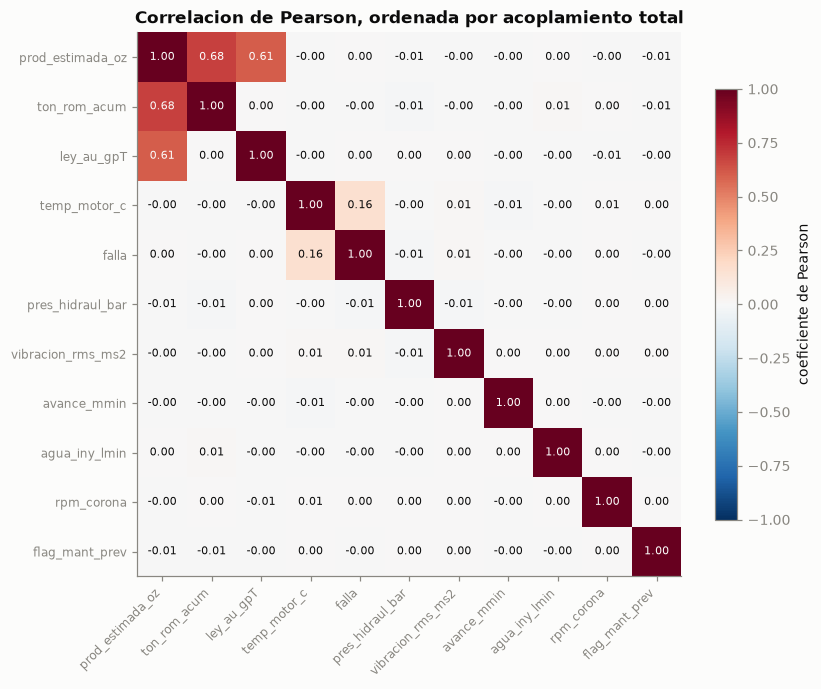

pares con |correlacion| > 0.10:
prod_estimada_oz  ton_rom_acum    0.682
                  ley_au_gpT      0.609
temp_motor_c      falla           0.160


In [6]:
# Matriz de correlacion de Pearson sobre los registros con lectura valida de ley.
# Se ordena por suma de correlaciones absolutas: las variables acopladas quedan juntas.
numericas = ["ley_au_gpT", "prod_estimada_oz", "ton_rom_acum", "pres_hidraul_bar",
             "rpm_corona", "avance_mmin", "agua_iny_lmin", "vibracion_rms_ms2",
             "temp_motor_c", "flag_mant_prev", "falla"]
corr_m = valida[numericas].astype(float).corr(method="pearson")
orden_corr = (corr_m.abs().sum() - 1).sort_values(ascending=False).index
corr_m = corr_m.loc[orden_corr, orden_corr]

fig, ax = plt.subplots(figsize=(7.6, 6.4))
im = ax.imshow(corr_m.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_m)))
ax.set_xticklabels(corr_m.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr_m)))
ax.set_yticklabels(corr_m.index, fontsize=8)
for y in range(len(corr_m)):
    for x in range(len(corr_m)):
        valor = corr_m.values[y, x]
        ax.text(x, y, f"{valor:.2f}", ha="center", va="center", fontsize=7,
                color=SURFACE if abs(valor) > 0.55 else INK)
ax.set_title("Correlacion de Pearson, ordenada por acoplamiento total")
fig.colorbar(im, ax=ax, shrink=0.75, label="coeficiente de Pearson")
plt.tight_layout()
plt.show()

triangulo = np.triu(np.ones(corr_m.shape), k=1).astype(bool)
pares = corr_m.where(triangulo).stack()
pares = pares[pares.abs() > 0.10].sort_values(key=abs, ascending=False)
print("pares con |correlacion| > 0.10:")
print(pares.round(3).to_string() if len(pares) else "  ninguno")

La matriz cierra la lectura de completitud con la de acoplamiento, y es casi toda blanca. Solo
tres pares pasan de 0.10 en valor absoluto:

- `prod_estimada_oz` con `ton_rom_acum` (0.68) y con `ley_au_gpT` (0.61), que son los dos
  factores de la relacion funcional que reconstruye la seccion 9.
- `temp_motor_c` con `falla` (0.16), un valor bajo para lo que en realidad es la senal mas
  fuerte del extracto: la tasa de falla pasa de 3.3% a 22% sobre los 95 C (seccion 15). La
  correlacion de Pearson mide relacion lineal y subestima una relacion de umbral, asi que esta
  matriz sirve para descartar redundancia, no para descartar variables.

Entre los sensores no hay ningun par acoplado: ninguno mide lo mismo que otro, no hay columnas
redundantes que eliminar, y ninguno se relaciona linealmente con la ley.

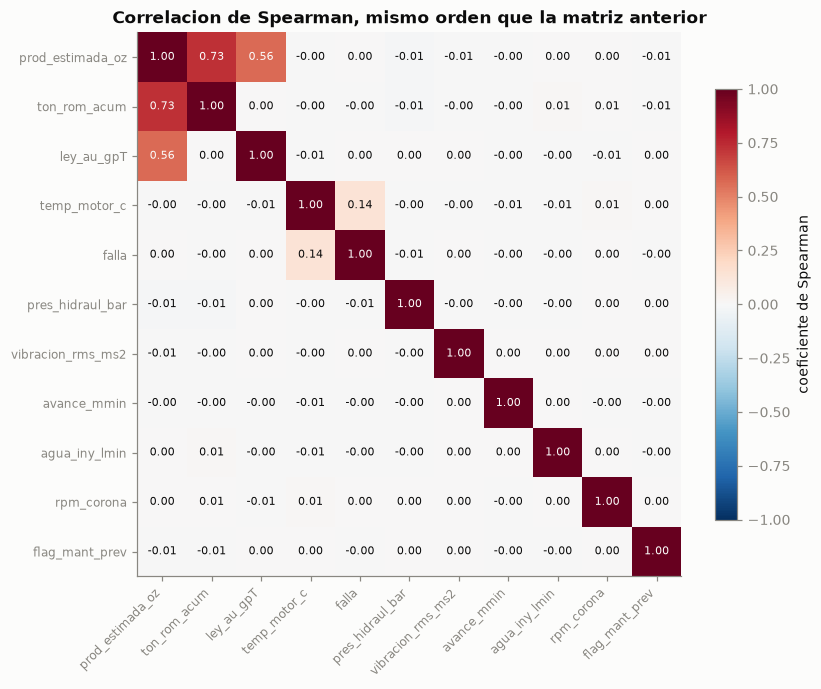

pares con |spearman| > 0.10:
                               pearson  spearman  gana_spearman
prod_estimada_oz ton_rom_acum    0.682     0.729          0.047
                 ley_au_gpT      0.609     0.563         -0.045
temp_motor_c     falla           0.160     0.137         -0.023

mayores diferencias a favor de Spearman (relacion monotona no lineal):
                                    pearson  spearman  gana_spearman
prod_estimada_oz ton_rom_acum         0.682     0.729          0.047
                 vibracion_rms_ms2   -0.002    -0.006          0.005
                 pres_hidraul_bar    -0.007    -0.010          0.003
temp_motor_c     agua_iny_lmin       -0.004    -0.007          0.003
ley_au_gpT       falla                0.002     0.004          0.002


In [7]:
# Spearman sobre las mismas variables y en el mismo orden, para poder comparar celda a celda.
# Pearson mide relacion lineal; Spearman, cualquier relacion monotona.
corr_s = valida[numericas].astype(float).corr(method="spearman").loc[orden_corr, orden_corr]

fig, ax = plt.subplots(figsize=(7.6, 6.4))
im = ax.imshow(corr_s.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_s)))
ax.set_xticklabels(corr_s.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr_s)))
ax.set_yticklabels(corr_s.index, fontsize=8)
for y in range(len(corr_s)):
    for x in range(len(corr_s)):
        valor = corr_s.values[y, x]
        ax.text(x, y, f"{valor:.2f}", ha="center", va="center", fontsize=7,
                color=SURFACE if abs(valor) > 0.55 else INK)
ax.set_title("Correlacion de Spearman, mismo orden que la matriz anterior")
fig.colorbar(im, ax=ax, shrink=0.75, label="coeficiente de Spearman")
plt.tight_layout()
plt.show()

comparacion_corr = pd.DataFrame({
    "pearson": corr_m.where(triangulo).stack(),
    "spearman": corr_s.where(triangulo).stack(),
})
comparacion_corr["gana_spearman"] = (comparacion_corr["spearman"].abs()
                                     - comparacion_corr["pearson"].abs())
print("pares con |spearman| > 0.10:")
fuertes = comparacion_corr[comparacion_corr["spearman"].abs() > 0.10]
print(fuertes.round(3).sort_values("spearman", key=abs, ascending=False).to_string())
print()
print("mayores diferencias a favor de Spearman (relacion monotona no lineal):")
print(comparacion_corr.sort_values("gana_spearman", ascending=False).head(5).round(3).to_string())

Spearman no descubre ninguna relacion que Pearson hubiera ocultado: los mismos tres pares
superan 0.10, ningun otro se acerca, y la mayor ganancia de Spearman en todo el triangulo es de
0.047. Los cambios que aparecen confirman lo que ya se sabia de cada variable en lugar de
agregar algo nuevo:

- `prod_estimada_oz` con `ton_rom_acum` sube de 0.68 a 0.73 y con `ley_au_gpT` baja de 0.61 a
  0.56. Es lo esperable en un producto de dos factores mas un tercero categorico: la relacion
  con cada factor es monotona a factor fijo, pero el otro la escala y el orden global se
  mezcla. Ni Pearson ni Spearman la reproducen; la seccion 9 la recupera exacta despejando la
  formula.
- `temp_motor_c` con `falla` baja levemente, de 0.16 a 0.14. Es la confirmacion de que la
  relacion no es monotona gradual sino de umbral: por debajo de 95 C la temperatura casi no
  mueve la tasa de falla, y por encima la multiplica por siete. Ningun coeficiente de
  correlacion, lineal o de rangos, representa bien eso; hay que verlo por tasas condicionales,
  como en la seccion 15.

Conclusion de las dos matrices juntas: fuera de la dependencia funcional de
`prod_estimada_oz`, en este extracto no hay pares de variables que se muevan juntas, ni de
forma lineal ni monotona.

## 2. `ts_opus_utc` — marca de tiempo del evento

Timestamp en UTC, unico por registro. Define el orden de todo el extracto y es el origen del
que se derivan el turno y la fecha local.

El archivo es un flujo de eventos ordenado en el tiempo. Antes de mirar el ritmo de cada
frente conviene mirar el del extracto completo, que es lo que revela como fue generado.

In [8]:
# Cadencia del extracto completo, sin separar por frente: un evento y el siguiente, sea cual sea
# el frente, el equipo o el operador.
cadencia = df["ts_opus_utc"].diff().dt.total_seconds().div(60).dropna()

print("Frecuencia de muestreo global (minutos entre eventos consecutivos del archivo)")
print(cadencia.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2).to_string())
print()
frecuencia = cadencia.value_counts().sort_index()
print(pd.DataFrame({"minutos": frecuencia.index.astype(int),
                    "pares": frecuencia.values,
                    "pct": (frecuencia.values / len(cadencia) * 100).round(2)}).to_string(index=False))

Frecuencia de muestreo global (minutos entre eventos consecutivos del archivo)
count    49999.00
mean        24.49
std          5.77
min         15.00
1%          15.00
25%         19.00
50%         25.00
75%         29.00
95%         34.00
99%         34.00
max         34.00

 minutos  pares  pct
      15   2540 5.08
      16   2434 4.87
      17   2552 5.10
      18   2498 5.00
      19   2556 5.11
      20   2499 5.00
      21   2533 5.07
      22   2373 4.75
      23   2539 5.08
      24   2446 4.89
      25   2565 5.13
      26   2436 4.87
      27   2547 5.09
      28   2504 5.01
      29   2518 5.04
      30   2546 5.09
      31   2492 4.98
      32   2410 4.82
      33   2463 4.93
      34   2548 5.10


In [9]:
# Pruebas de simultaneidad: si diez equipos perforaran en paralelo, tendrian que solaparse.
por_ts = df.groupby("ts_opus_utc")
pruebas = pd.DataFrame([
    {"prueba": "timestamps duplicados",
     "observado": int(df["ts_opus_utc"].duplicated().sum()), "esperado_si_hay_paralelismo": "> 0"},
    {"prueba": "eventos en el mismo minuto calendario (max)",
     "observado": int(df.groupby(df["ts_opus_utc"].dt.floor("min")).size().max()), "esperado_si_hay_paralelismo": "> 1"},
    {"prueba": "frentes distintos en el mismo instante (max)",
     "observado": int(por_ts["frente_id"].nunique().max()), "esperado_si_hay_paralelismo": "> 1"},
    {"prueba": "equipos distintos en el mismo instante (max)",
     "observado": int(por_ts["equipo_id"].nunique().max()), "esperado_si_hay_paralelismo": "> 1"},
    {"prueba": "registros con segundos distintos de 00",
     "observado": int((df["ts_opus_utc"].dt.second != 0).sum()), "esperado_si_hay_paralelismo": "> 0"},
])
print(pruebas.to_string(index=False))
print()
print("eventos por dia calendario:")
print(df.groupby(df["ts_opus_utc"].dt.date).size().describe().round(2).to_string())
print()
por_turno = (df.assign(fecha_local=(df["ts_opus_utc"] - pd.Timedelta(hours=5)).dt.date)
               .groupby(["fecha_local", "turno_cod"]))
print("por turno-fecha: equipos distintos (media)", round(por_turno["equipo_id"].nunique().mean(), 2),
      "| frentes distintos (mediana)", int(por_turno["frente_id"].nunique().median()),
      "| registros (media)", round(por_turno.size().mean(), 1))

                                      prueba  observado esperado_si_hay_paralelismo
                       timestamps duplicados          0                         > 0
 eventos en el mismo minuto calendario (max)          1                         > 1
frentes distintos en el mismo instante (max)          1                         > 1
equipos distintos en el mismo instante (max)          1                         > 1
      registros con segundos distintos de 00          0                         > 0

eventos por dia calendario:
count    851.00
mean      58.75
std        2.31
min       20.00
25%       58.00
50%       59.00
75%       60.00
max       66.00

por turno-fecha: equipos distintos (media) 7.85 | frentes distintos (mediana) 1 | registros (media) 14.7


La cadencia global es **uniforme discreta entre 15 y 34 minutos**: cada valor entero de ese
rango aparece en cerca del 5% de los pares, nunca menos de 15 ni mas de 34, y todos los
timestamps caen en el segundo 00. Un proceso fisico de perforacion no produce una distribucion
plana y acotada asi; un generador que sortea el siguiente instante en un rango fijo, si.

Las pruebas de simultaneidad lo confirman por otro lado: **el extracto no tiene un solo evento
simultaneo**. Cero timestamps repetidos, nunca dos registros en el mismo minuto, jamas dos
frentes ni dos equipos a la vez. Con diez equipos y trece frentes eso es imposible en una
operacion real: diez perforadoras trabajando en paralelo se solapan en el tiempo por
construccion. El detalle que lo remata es que en un mismo turno y fecha aparecen en promedio
7.85 equipos distintos sobre un solo frente (mediana) en unos 15 registros: ocho perforadoras
rotando en el mismo frente durante seis horas, nunca a la vez.

### Supuesto adoptado

Ante dos lecturas posibles — que el extracto describa una sola maquina real o que sea un
extracto sintetico con las etiquetas repartidas al azar sobre un flujo unico — **se adopta la
segunda**, porque es la unica que explica todo lo observado a la vez: la cadencia uniforme y
acotada, los segundos siempre en 00, la ausencia total de simultaneidad, y lo que se vera en
las secciones 18 y 19 — cada equipo aparece en los trece frentes, cada operador en los diez
equipos, y las leyes medias y las tasas de falla son planas entre unos y otros. La lectura de
"una sola maquina" explicaria la serializacion pero no la uniformidad de la cadencia ni el
reparto perfecto de etiquetas.

El supuesto se enuncia como supuesto, no como hecho sobre la unidad minera: lo demostrado es
que el archivo es un flujo estrictamente serial de unos 59 eventos por dia y que `equipo_id`
no puede representar diez perforadoras operando en paralelo.

**Que implica adoptarlo.** `equipo_id` y `op_id` quedan fuera de toda lectura causal: no se
concluye nada sobre el desempeno de una maquina ni de una cuadrilla, y buscarles senal es
perseguir ruido. El orden temporal del archivo es orden de emision, no secuencia de operacion
concurrente, de modo que no tiene sentido preguntarse que ocurria en la mina en un instante
dado. Nada de esto alcanza a `ley_au_gpT`, `frente_id` ni `sector_geol`: su estructura interna
es consistente — jerarquia limpia, separacion de 12.4 g/t entre frentes, centinela con un
patron claro por turno — y ahi esta la senal aprovechable del extracto.

**Advertencia, no bloqueo.** Las implicaciones causales anteriores pueden dejarse de lado
deliberadamente para continuar con el trabajo: si lo que se pide es tratar `equipo_id` y
`op_id` como cualquier otra variable, se hace, y el resultado sera tecnicamente correcto
aunque no signifique nada sobre maquinas ni operadores. Lo que no puede pasar es que la
advertencia se pierda: queda registrada aqui para que cualquier conclusion que se apoye en
esas dos columnas se lea sabiendo que describe la construccion del archivo y no la operacion
minera.

In [10]:
ts = df["ts_opus_utc"]
span_meses = (ts.max() - ts.min()).days / 30.44
print(f"inicio : {ts.min()}")
print(f"fin    : {ts.max()}")
print(f"span   : {span_meses:.1f} meses  (el enunciado describe 18)")

gaps = df.sort_values("ts_opus_utc").groupby("frente_id")["ts_opus_utc"].diff().dt.total_seconds().div(60)
print()
print("intervalo entre eventos del mismo frente (minutos):")
print(gaps.describe(percentiles=[0.25, 0.5, 0.75, 0.95]).round(1).to_string())

print()
print("huecos de mas de 7 dias dentro de un frente:", int((gaps > 7 * 1440).sum()))
por_frente_mes = df.groupby(["frente_id", df["ts_opus_utc"].dt.to_period("M")]).size().unstack(fill_value=0)
meses_vacios = (por_frente_mes == 0).sum(axis=1)
print(f"meses sin registros por frente: de {meses_vacios.min()} a {meses_vacios.max()}"
      f" sobre {por_frente_mes.shape[1]} meses cubiertos")


inicio : 2023-07-01 00:16:00
fin    : 2025-10-28 07:59:00
span   : 27.9 meses  (el enunciado describe 18)

intervalo entre eventos del mismo frente (minutos):
count     49987.0
mean        307.9
std        3407.9
min          15.0
25%          20.0
50%          25.0
75%          30.0
95%          34.0
max      166274.0

huecos de mas de 7 dias dentro de un frente: 422
meses sin registros por frente: de 2 a 6 sobre 28 meses cubiertos


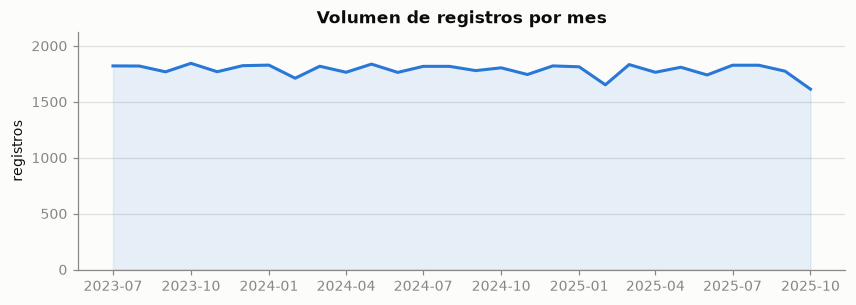

In [11]:
por_mes = df.set_index("ts_opus_utc").resample("MS").size()

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(por_mes.index, por_mes.values, color=SERIES[0], linewidth=2)
ax.fill_between(por_mes.index, por_mes.values, color=SERIES[0], alpha=0.10)
ax.set_ylim(0, por_mes.max() * 1.15)
ax.set_ylabel("registros")
ax.set_title("Volumen de registros por mes")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.show()

**Que es un "par".** Las dos figuras que siguen no cuentan registros sino **pares de eventos
consecutivos dentro de un mismo frente**: se ordena el extracto por tiempo, se agrupa por
`frente_id` y se toma la diferencia entre cada evento y el anterior *de ese frente*. El primer
evento de cada frente no tiene anterior, asi que quedan 50000 - 13 = **49987 pares**, cada uno
con una duracion en minutos. Medir la diferencia sin separar por frente daria otra cosa: el
ritmo agregado de la unidad, donde trece frentes en paralelo se pisan entre si.

**Como leer los dos paneles.**

- *Izquierda*: solo los pares de hasta 60 minutos, que son el 98.65% del total, con un bin por
  minuto. La distribucion es plana entre 15 y 34 minutos y **no hay ningun par por debajo de
  15**: es el piso de muestreo del sistema OPUS, no un fenomeno geologico. Este panel es la
  cadencia real de perforacion.
- *Derecha*: los 49987 pares, ahora en dias y en escala logaritmica, que es la unica forma de
  ver a la vez un intervalo de 20 minutos y uno de 115 dias. La caja va de 0.014 a 0.021 dias
  (20 a 30 minutos) y por eso aparece como una franja finisima a la izquierda: la mitad central
  de los datos ocupa diez minutos de ancho. La nube de puntos que se extiende a la derecha son
  los valores atipicos del criterio de Tukey, 675 pares por encima de 45 minutos, y ahi estan
  las 635 pausas de mas de un dia.

Los dos paneles miden lo mismo y cuentan cosas opuestas. Esa es la razon de ponerlos juntos: la
variable no tiene un solo comportamiento, tiene dos regimenes.

/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/2769831103.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(huecos / 1440, **BOX_STYLE)


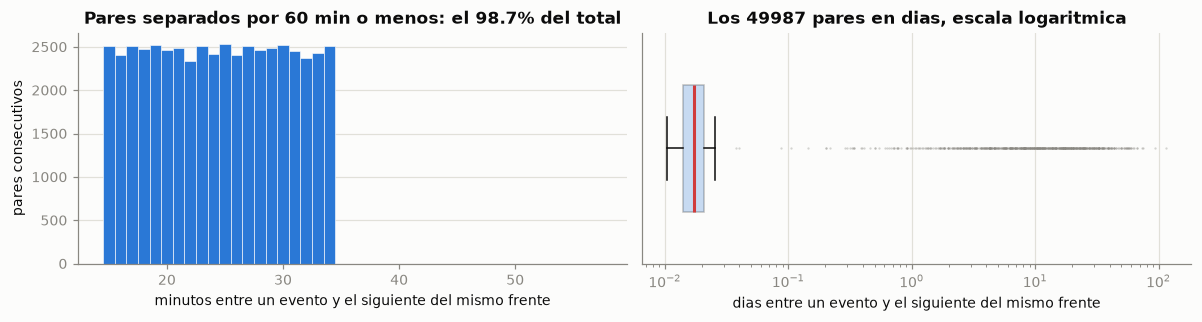

In [12]:
huecos = gaps.dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.0))
cortos = huecos[huecos <= 60]
axes[0].hist(cortos, bins=np.arange(cortos.min() - 0.5, cortos.max() + 1.5, 1),
             color=SERIES[0], edgecolor=SURFACE, linewidth=0.4)
axes[0].set_title("Pares separados por 60 min o menos: el 98.7% del total")
axes[0].set_xlabel("minutos entre un evento y el siguiente del mismo frente")
axes[0].set_ylabel("pares consecutivos")
axes[0].grid(axis="y")
axes[0].set_axisbelow(True)

axes[1].boxplot(huecos / 1440, **BOX_STYLE)
axes[1].set_xscale("log")
axes[1].set_yticks([])
axes[1].set_title("Los 49987 pares en dias, escala logaritmica")
axes[1].set_xlabel("dias entre un evento y el siguiente del mismo frente")
axes[1].grid(axis="x")
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

El contraste entre los dos paneles anticipa el problema de resumir esta variable con un solo
numero. La descomposicion siguiente lo cuantifica.

In [13]:
# Que desplaza la media de 25 a 308 minutos: descomposicion del tiempo por tramo de hueco.
TRAMOS = [(0, 60, "hasta 1 h"), (60, 1440, "1 h a 1 dia"),
          (1440, 10080, "1 a 7 dias"), (10080, np.inf, "mas de 7 dias")]

filas = []
for lo, hi, etiqueta in TRAMOS:
    m = (huecos > lo) & (huecos <= hi)
    filas.append({
        "tramo": etiqueta,
        "pares": int(m.sum()),
        "pct_pares": round(m.mean() * 100, 2),
        "aporte_a_la_media_min": round(huecos[m].sum() / len(huecos), 1),
        "pct_del_tiempo": round(huecos[m].sum() / huecos.sum() * 100, 1),
    })
descomposicion = pd.DataFrame(filas)
print(descomposicion.to_string(index=False))
print()
print(f"media = {huecos.mean():.1f} min | mediana = {huecos.median():.0f} min")

pausas = df.loc[huecos[huecos > 1440].index].assign(dias=(huecos[huecos > 1440] / 1440))
print()
print("pausas de mas de un dia:", len(pausas))
print((pausas["dias"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])).round(1).to_string())
print()
print("pausas por frente:", pausas["frente_id"].value_counts().min(), "a",
      pausas["frente_id"].value_counts().max(), "cada uno")
print("pausas por mes de reinicio:", pausas["ts_opus_utc"].dt.to_period("M").value_counts().min(), "a",
      pausas["ts_opus_utc"].dt.to_period("M").value_counts().max())
print()
gap_global = df["ts_opus_utc"].diff().dt.total_seconds().div(60).dropna()
print(f"hueco maximo del extracto completo, sin separar por frente: {gap_global.max():.0f} min")

        tramo  pares  pct_pares  aporte_a_la_media_min  pct_del_tiempo
    hasta 1 h  49314      98.65                   24.2             7.8
  1 h a 1 dia     38       0.08                    0.6             0.2
   1 a 7 dias    213       0.43                   24.0             7.8
mas de 7 dias    422       0.84                  259.2            84.2

media = 307.9 min | mediana = 25 min

pausas de mas de un dia: 635
count    635.0
mean      15.5
std       14.3
min        1.0
25%        5.4
50%       10.8
75%       21.0
95%       43.4
max      115.5

pausas por frente: 40 a 60 cada uno
pausas por mes de reinicio: 11 a 34

hueco maximo del extracto completo, sin separar por frente: 34 min


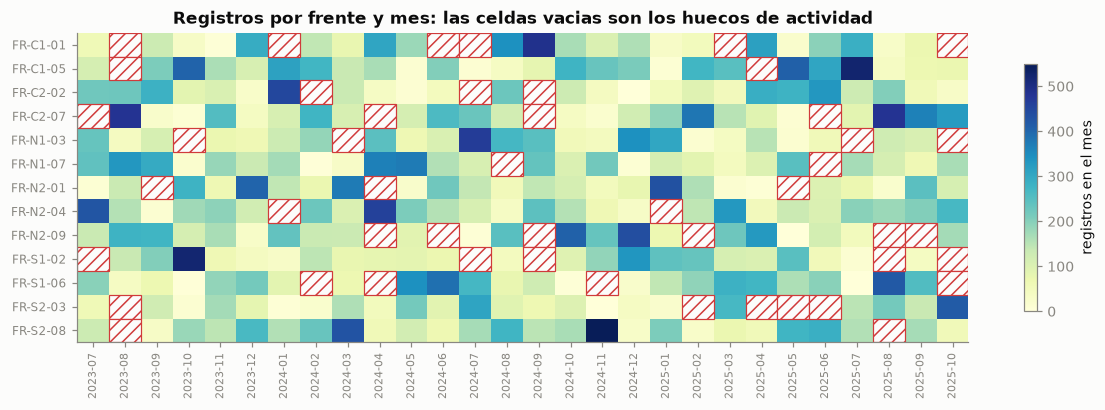

In [14]:
actividad = (df.groupby(["frente_id", df["ts_opus_utc"].dt.to_period("M")])
               .size().unstack(fill_value=0).sort_index())
meses = [str(m) for m in actividad.columns]

fig, ax = plt.subplots(figsize=(11, 3.8))
im = ax.imshow(actividad.values, aspect="auto", cmap="YlGnBu", vmin=0)
ax.set_xticks(range(len(meses)))
ax.set_xticklabels(meses, rotation=90, fontsize=7)
ax.set_yticks(range(len(actividad.index)))
ax.set_yticklabels(actividad.index, fontsize=8)
ax.set_title("Registros por frente y mes: las celdas vacias son los huecos de actividad")
for y, x in zip(*np.where(actividad.values == 0)):
    ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, facecolor=SURFACE,
                               edgecolor=CRITICAL, linewidth=0.8, hatch="///"))
fig.colorbar(im, ax=ax, shrink=0.8, label="registros en el mes")
plt.tight_layout()
plt.show()

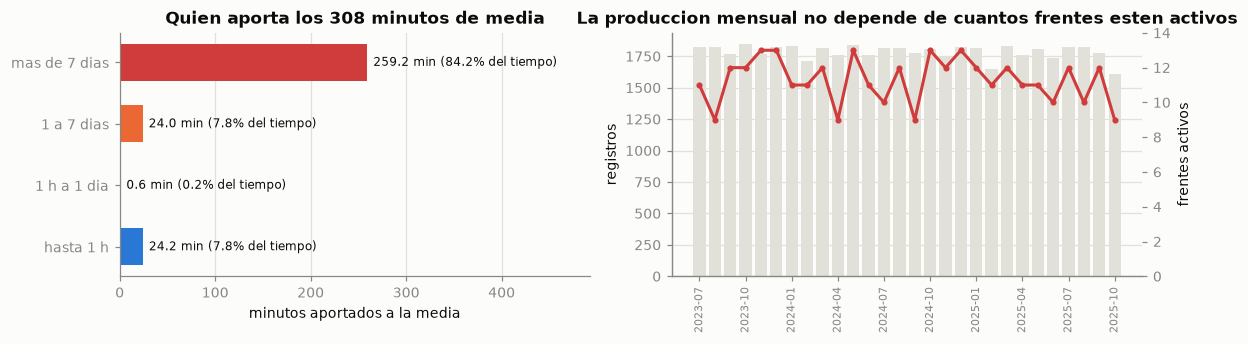

In [15]:
frentes_activos = (actividad > 0).sum(axis=0)
registros_mes = actividad.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

barras = axes[0].barh(descomposicion["tramo"], descomposicion["aporte_a_la_media_min"],
                      color=[SERIES[0], SERIES[0], SERIES[1], CRITICAL], height=0.6)
axes[0].bar_label(barras, labels=[f"{v} min ({p}% del tiempo)" for v, p in
                                  zip(descomposicion["aporte_a_la_media_min"],
                                      descomposicion["pct_del_tiempo"])],
                  padding=4, color=INK, fontsize=8)
axes[0].set_xlim(0, descomposicion["aporte_a_la_media_min"].max() * 1.9)
axes[0].set_title("Quien aporta los 308 minutos de media")
axes[0].set_xlabel("minutos aportados a la media")
axes[0].grid(axis="x")
axes[0].set_axisbelow(True)

x = range(len(frentes_activos))
axes[1].bar(x, registros_mes.values, color=GRID, label="registros del mes")
axes[1].set_ylabel("registros")
gemelo = axes[1].twinx()
gemelo.plot(x, frentes_activos.values, color=CRITICAL, linewidth=2, marker="o",
            markersize=3, label="frentes activos")
gemelo.set_ylim(0, df["frente_id"].nunique() + 1)
gemelo.set_ylabel("frentes activos")
axes[1].set_xticks(list(x)[::3])
axes[1].set_xticklabels([str(m) for m in frentes_activos.index][::3], rotation=90, fontsize=7)
axes[1].set_title("La produccion mensual no depende de cuantos frentes esten activos")
axes[1].grid(axis="y")
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

**Que desplaza la media.** El 98.7% de los pares consecutivos esta separado por una hora o
menos y aporta 24 de los 308 minutos de media: ese es el ritmo real de perforacion. Los 308
minutos los pone el 0.84% de pares separados por mas de siete dias, que concentra el **84% del
tiempo transcurrido** del extracto. Entre una hora y un dia casi no hay nada: 38 pares en
cincuenta mil. La distribucion no es de cola larga, es **bimodal** — se perfora cada 25 minutos
o el frente se detiene por semanas, sin termino medio.

Esas pausas largas son 635, con mediana de 10.8 dias y maximo de 115, y estan repartidas de forma
uniforme: entre 40 y 60 por frente, entre 11 y 34 por mes de reinicio, sin concentrarse en
ningun frente ni en ningun periodo del calendario. No son paradas de la unidad minera: **el
extracto completo, sin separar por frente, nunca tiene un hueco de mas de 34 minutos.** La
operacion no se detiene nunca; lo que rota es en cuales frentes trabaja, y en cualquier mes hay
entre 9 y 13 frentes activos mientras el volumen mensual se mantiene entre 1613 y 1844
registros. La cuadrilla se mueve, la produccion no cae.

Para leer la variable: la media del intervalo entre eventos de un frente no describe nada del
proceso, porque mezcla dos fenomenos distintos. La cadencia de perforacion es la mediana, 25
minutos; la disponibilidad del frente es la cuenta de pausas, y son dos cosas que hay que mirar
por separado.

El extracto va del 2023-07-01 al 2025-10-28: **27.9 meses**, no los 18 que describe el
enunciado. La cadencia dentro de un frente activo es de 25 minutos entre eventos (mediana),
con un cuartil superior de 30 minutos, pero la media de 308 minutos revela que los frentes no
estan siempre activos: 422 huecos superan la semana y cada frente pasa entre dos y seis meses
sin un solo registro. El mapa de calor lo muestra de frente: las celdas rayadas son meses en
los que un frente no registro un solo evento, y ninguna columna las tiene todas, de modo que
la operacion rota entre frentes en lugar de detenerse.

El volumen mensual del extracto completo, en cambio, es plano: la rotacion no cambia el ritmo
agregado, y no hay estacionalidad de produccion, huecos de meses completos ni un tramo inicial
de arranque que descartar.

## 3. `turno_cod` — turno operacional

Cuatro categorias (D1, D2, N1, N2) repartidas casi por igual, unas 12500 filas cada una. El
diccionario no dice como se asigna el turno ni en que zona horaria opera la unidad; el cruce
con la hora del timestamp responde las dos preguntas.

In [16]:
turno_hora = pd.crosstab(df["ts_opus_utc"].dt.hour, df["turno_cod"])
turno_hora = turno_hora[["D1", "D2", "N1", "N2"]]
print("Horas UTC cubiertas por cada turno:")
for turno in turno_hora.columns:
    horas = sorted(turno_hora.index[turno_hora[turno] > 0].tolist())
    print(f"  {turno}: {horas}")
print()
print("filas donde la hora UTC no determina el turno:",
      int((turno_hora.gt(0).sum(axis=1) > 1).sum()))

Horas UTC cubiertas por cada turno:
  D1: [11, 12, 13, 14, 15, 16]
  D2: [17, 18, 19, 20, 21, 22]
  N1: [0, 1, 2, 3, 4, 23]
  N2: [5, 6, 7, 8, 9, 10]

filas donde la hora UTC no determina el turno: 0


/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:139: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot([valida.loc[valida[col] == k, valor].dropna().values for k in orden],


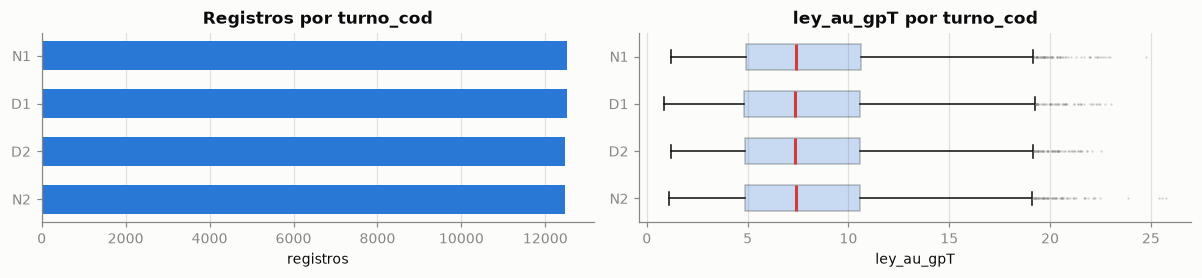

,registros,ley_media,falla_pct
turno_cod,,,
N1,12527,8.02,3.31
D1,12513,7.99,3.28
D2,12480,7.99,3.37
N2,12480,7.99,3.31


In [17]:
perfil_categorica("turno_cod")

Cada hora UTC pertenece a un unico turno, con fronteras en 05:00, 11:00, 17:00 y 23:00 UTC:
`turno_cod` es una funcion determinista de `ts_opus_utc` y no aporta informacion independiente.
Restando cinco horas se obtienen turnos de seis horas que empiezan a las 00:00, 06:00, 12:00 y
18:00 hora local, de modo que **la zona operacional es UTC-5** y el orden cronologico del dia
local es N2, D1, D2, N1. El dato importa porque el archivo no declara la zona horaria en
ninguna parte.

## 4. `frente_id` — frente de trabajo

Trece frentes identificados con el patron `FR-<zona><n>-<nn>`. Es la variable de ubicacion mas
fina del extracto.

/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:139: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot([valida.loc[valida[col] == k, valor].dropna().values for k in orden],


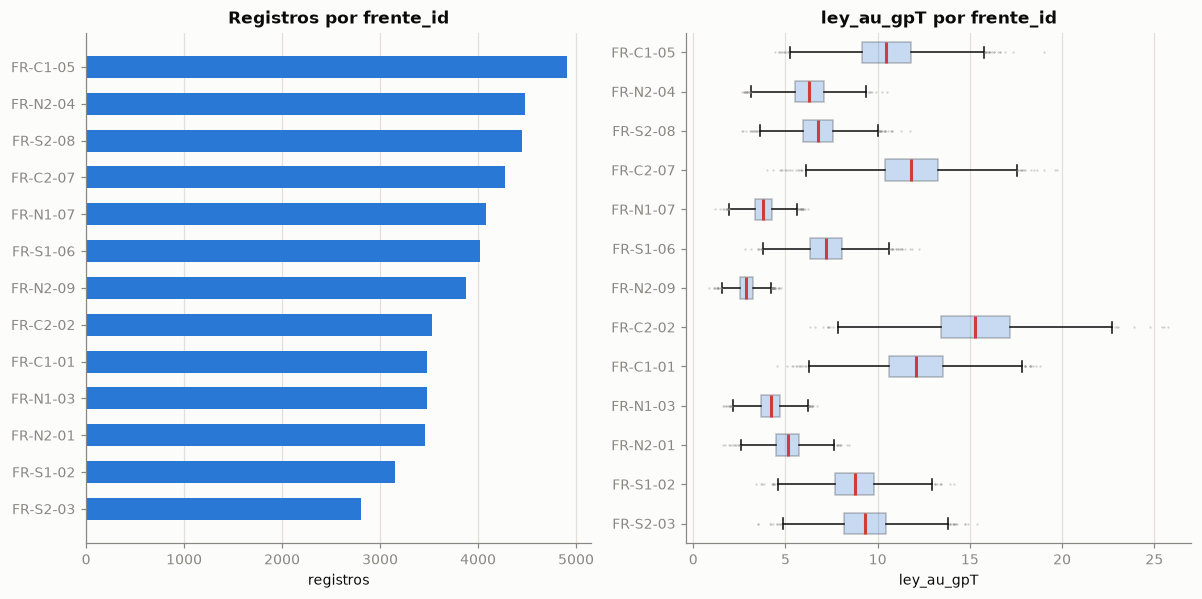

,registros,ley_media,falla_pct
frente_id,,,
FR-C1-05,4908,10.48,3.38
FR-N2-04,4477,6.28,3.40
FR-S2-08,4453,6.79,3.19
FR-C2-07,4277,11.81,3.23
FR-N1-07,4081,3.80,2.94
FR-S1-06,4022,7.19,3.18
FR-N2-09,3875,2.89,2.92
FR-C2-02,3528,15.30,3.34
FR-C1-01,3483,12.10,3.53


In [18]:
perfil_categorica("frente_id")

In [19]:
por_frente = valida.groupby("frente_id")["ley_au_gpT"].mean().sort_values()
print(f"ley media por frente: {por_frente.min():.2f} a {por_frente.max():.2f} g/t "
      f"(amplitud {por_frente.max() - por_frente.min():.2f})")

ley media por frente: 2.89 a 15.30 g/t (amplitud 12.41)


El frente es la variable que mas separa la ley de todo el extracto: la media va de 2.9 a
15.3 g/t, cinco veces entre el frente mas pobre y el mas rico. La tasa de falla, en cambio, es
practicamente la misma en todos (entre 2.9% y 3.9%), asi que el frente describe geologia, no
condicion mecanica.

## 5. `sector_geol` — sector geologico

Cuatro sectores. No es una variable independiente de `frente_id`: el prefijo de zona del codigo
de frente determina el sector.

frente_id      FR-C1-01 FR-C1-05 FR-C2-02 FR-C2-07 FR-N1-03 FR-N1-07 FR-N2-01 FR-N2-04 FR-N2-09 FR-S1-02 FR-S1-06 FR-S2-03 FR-S2-08
sector_geol                                                                                                                        
Cuerpo-Central     3483     4908                                                                                                   
Rampa-Norte                                            3481     4081     3459     4477     3875                                    
Veta-Principal                       3528     4277                                                                                 
Veta-Sur                                                                                            3155     4022     2801     4453

sectores distintos por frente: 1


/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:139: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot([valida.loc[valida[col] == k, valor].dropna().values for k in orden],


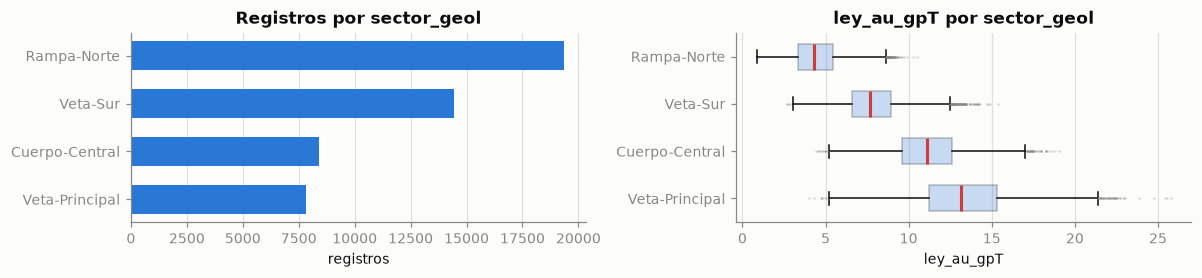

,registros,ley_media,falla_pct
sector_geol,,,
Rampa-Norte,19373,4.52,3.27
Veta-Sur,14431,7.82,3.33
Cuerpo-Central,8391,11.15,3.44
Veta-Principal,7805,13.38,3.28


In [20]:
print(pd.crosstab(df["sector_geol"], df["frente_id"]).replace(0, "").to_string())
print()
print("sectores distintos por frente:", int(df.groupby("frente_id")["sector_geol"].nunique().max()))
perfil_categorica("sector_geol")

Cada frente pertenece a un unico sector: `frente_id` y `sector_geol` son la misma jerarquia a
dos granularidades, trece nodos contra cuatro. La ley media por sector va de 4.5 g/t en
Rampa-Norte a 13.4 g/t en Veta-Principal, un rango mas estrecho que el de frente porque agrega
frentes de leyes distintas dentro de un mismo sector.

## 6. `tipo_mineral` — tipo de mineral

Cuatro categorias: OX (oxido), SUL (sulfuro), MIX (mixto) y EST (esteril). Las tres primeras
reparten unos 14300 registros cada una y EST la mitad, 7140.

/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:139: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot([valida.loc[valida[col] == k, valor].dropna().values for k in orden],


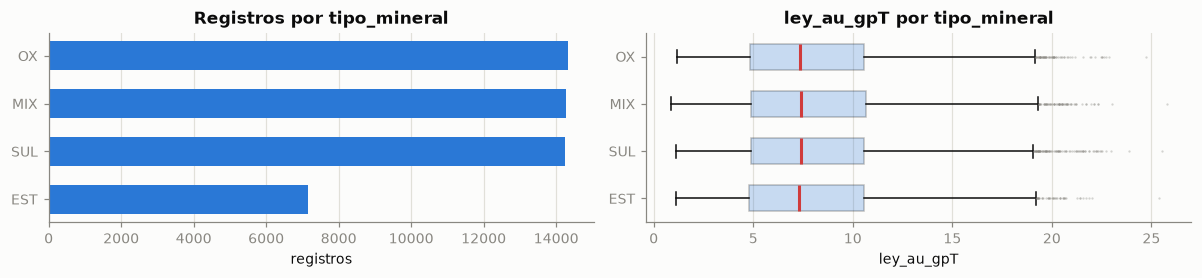

,registros,ley_media,falla_pct
tipo_mineral,,,
OX,14320,7.97,3.22
MIX,14284,8.03,3.51
SUL,14256,8.01,3.25
EST,7140,7.97,3.25


In [21]:
perfil_categorica("tipo_mineral")

El tipo de mineral **no discrimina la ley**: las medias van de 7.97 a 8.03 g/t, un rango de
0.06 contra los 12.4 de `frente_id`. Es contraintuitivo desde el dominio y conviene declararlo:
en este extracto el tipo de mineral no describe cuanto oro hay sino como se recupera, y su
efecto aparece completo en `prod_estimada_oz` a traves del factor de recuperacion metalurgica
(seccion 9). Tampoco separa la tasa de falla.

## 7. `ley_au_gpT` — ley de oro, la variable objetivo

Gramos de oro por tonelada medidos con sonda XRF. El enunciado advierte que "puede contener
valores especiales": no son nulos, estan codificados dentro del rango numerico.

In [22]:
ley = df["ley_au_gpT"]
print(ley.describe().round(4).to_string())
print()
print("valores negativos:", int((ley < 0).sum()), "| valores distintos negativos:", sorted(ley[ley < 0].unique()))
print("valores en cero  :", int((ley == 0).sum()))
print("nulos declarados :", int(ley.isna().sum()))

count    50000.0000
mean         7.4927
std          4.2761
min         -1.0000
25%          4.4118
50%          7.0836
75%         10.3580
max         25.7603

valores negativos: 2810 | valores distintos negativos: [np.float64(-1.0)]
valores en cero  : 0
nulos declarados : 0


El unico valor negativo es exactamente `-1.0`, en 2810 registros (5.6%). Una ley de oro negativa
no existe fisicamente: es el codigo de "sin lectura valida de la sonda". Cualquier estadistica
que lo incluya como si fuera una medicion queda contaminada. Descontados esos registros, la ley
va de 0.87 a 25.76 g/t con media de 8.0.

/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:87: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(serie.dropna(), **BOX_STYLE)
/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


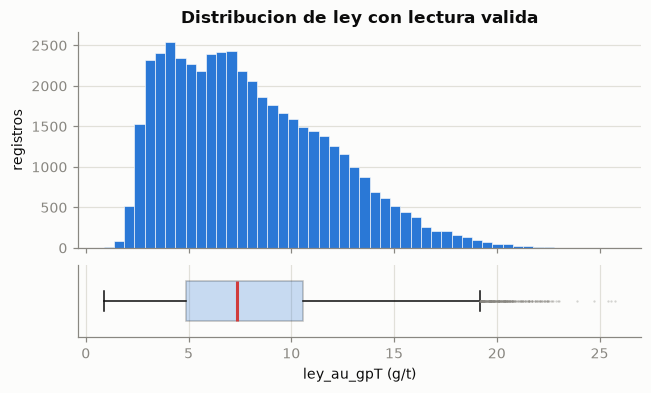

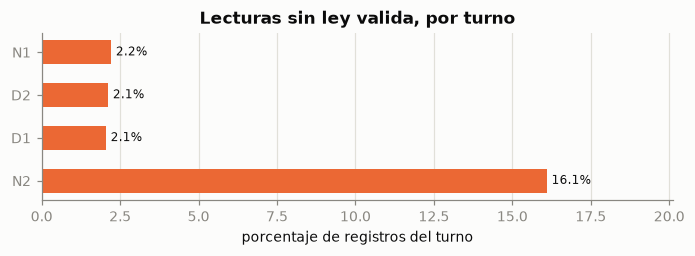

In [23]:
hist_box(valida["ley_au_gpT"], "Distribucion de ley con lectura valida", "ley_au_gpT (g/t)")

tasa = df.groupby("turno_cod")["ley_sentinela"].mean().mul(100).reindex(["N2", "D1", "D2", "N1"])
fig, ax = plt.subplots(figsize=(6.4, 2.4))
barras = ax.barh(tasa.index, tasa.values, color=SERIES[1], height=0.55)
ax.bar_label(barras, fmt="%.1f%%", padding=3, color=INK, fontsize=8)
ax.set_xlim(0, tasa.max() * 1.25)
ax.set_title("Lecturas sin ley valida, por turno")
ax.set_xlabel("porcentaje de registros del turno")
ax.grid(axis="x")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

La ausencia de lectura **no es aleatoria**: el turno N2 concentra el 16.1% de sus registros sin
ley, frente a cerca del 2% en los otros tres. Es un faltante condicionado a una variable
observada, no un faltante completamente al azar, y por lo tanto los registros sin ley no son
intercambiables con el resto.

In [24]:
ventana = (df.assign(fecha=df["ts_opus_utc"].dt.floor("D"))
             .loc[~df["ley_sentinela"]]
             .groupby(["frente_id", "tipo_mineral"])
             .size())
print("registros con ley valida por combinacion frente x tipo_mineral:")
print(ventana.describe().round(1).to_string())
print()
print("combinaciones existentes:", len(ventana), "de", df["frente_id"].nunique() * df["tipo_mineral"].nunique(), "posibles")

registros con ley valida por combinacion frente x tipo_mineral:
count      52.0
mean      907.5
std       270.8
min       357.0
25%       731.8
50%       943.5
75%      1117.5
max      1359.0

combinaciones existentes: 52 de 52 posibles


In [25]:
comparacion = pd.DataFrame({
    "por sector_geol": valida.groupby("sector_geol")["ley_au_gpT"].mean().agg(["min", "max"]),
    "por frente_id": valida.groupby("frente_id")["ley_au_gpT"].mean().agg(["min", "max"]),
    "por tipo_mineral": valida.groupby("tipo_mineral")["ley_au_gpT"].mean().agg(["min", "max"]),
    "por turno_cod": valida.groupby("turno_cod")["ley_au_gpT"].mean().agg(["min", "max"]),
}).T
comparacion["rango"] = (comparacion["max"] - comparacion["min"]).round(2)
comparacion.round(2)

,min,max,rango
por sector_geol,4.52,13.38,8.87
por frente_id,2.89,15.30,12.41
por tipo_mineral,7.97,8.03,0.06
por turno_cod,7.99,8.02,0.04


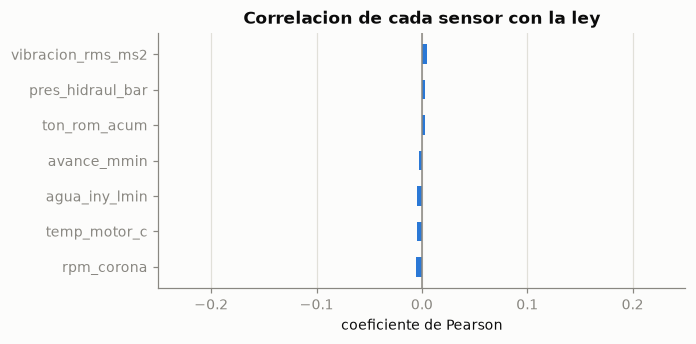

In [26]:
sensores = ["pres_hidraul_bar", "rpm_corona", "avance_mmin", "agua_iny_lmin",
            "vibracion_rms_ms2", "temp_motor_c", "ton_rom_acum"]
corr = valida[sensores + ["ley_au_gpT"]].corr()["ley_au_gpT"].drop("ley_au_gpT").sort_values()

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.barh(corr.index, corr.values, color=SERIES[0], height=0.55)
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_xlim(-0.25, 0.25)
ax.set_title("Correlacion de cada sensor con la ley")
ax.set_xlabel("coeficiente de Pearson")
ax.grid(axis="x")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Que explica la ley: la ubicacion, no la maquina. Ningun sensor supera 0.01 de correlacion con
ella, mientras que agrupar por frente separa 12.4 g/t entre extremos y por sector 8.9. Es lo
que dice el dominio — la ley es una propiedad del macizo rocoso y los sensores describen como
se perfora, no cuanto oro hay — y aqui queda medido.

El grupo natural para caracterizar una ley faltante a partir de sus vecinas es la combinacion
frente por tipo de mineral: existen las 52 combinaciones posibles y ninguna baja de varios
centenares de registros con lectura valida.

## 8. `ton_rom_acum` — tonelaje

El diccionario lo define como toneladas de mineral acumuladas en el turno. Si lo fuera, dentro
de un mismo frente, fecha y turno la serie tendria que ser creciente.

count    50000.00
mean       230.20
std        104.17
min         24.61
25%        139.66
50%        221.85
75%        320.50
max        419.99


/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:87: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(serie.dropna(), **BOX_STYLE)
/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


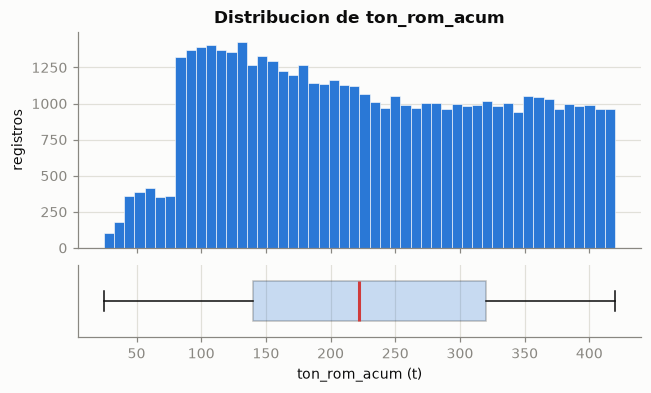

In [27]:
print(df["ton_rom_acum"].describe().round(2).to_string())
hist_box(df["ton_rom_acum"], "Distribucion de ton_rom_acum", "ton_rom_acum (t)")

In [28]:
orden = df.sort_values("ts_opus_utc").assign(fecha_local=lambda d: (d["ts_opus_utc"] - pd.Timedelta(hours=5)).dt.date)
monotona = (orden.groupby(["frente_id", "fecha_local", "turno_cod"])["ton_rom_acum"]
                 .apply(lambda s: bool(s.is_monotonic_increasing)))
print(f"grupos frente x fecha x turno      : {len(monotona):,}")
print(f"con ton_rom_acum creciente         : {monotona.mean() * 100:.1f}%")
print(f"registros por grupo (mediana)      : {orden.groupby(['frente_id', 'fecha_local', 'turno_cod']).size().median():.0f}")

grupos frente x fecha x turno      : 4,019
con ton_rom_acum creciente         : 4.0%
registros por grupo (mediana)      : 14


In [29]:
# Un turno cualquiera, aislado: el de mas registros del extracto.
grupos = orden.groupby(["frente_id", "fecha_local", "turno_cod"])
clave = grupos.size().idxmax()
turno = grupos.get_group(clave).sort_values("ts_opus_utc")

print("turno aislado:", clave, f"({len(turno)} registros)")
print(turno[["ts_opus_utc", "ton_rom_acum", "ley_au_gpT"]].to_string(index=False))

saltos = turno["ton_rom_acum"].diff().dropna()
print()
print(f"descensos dentro del turno : {int((saltos < 0).sum())} de {len(saltos)} transiciones")
print(f"maximo del turno           : {turno['ton_rom_acum'].max():.2f} t")
print(f"suma del turno             : {turno['ton_rom_acum'].sum():.2f} t")

turno aislado: ('FR-C1-05', datetime.date(2025, 7, 2), 'N1') (18 registros)
        ts_opus_utc  ton_rom_acum  ley_au_gpT
2025-07-02 23:04:00    332.330000     10.3464
2025-07-02 23:27:00     53.434709     -1.0000
2025-07-02 23:48:00    162.700000      7.4846
2025-07-03 00:08:00    295.920000      7.7433
2025-07-03 00:29:00    116.840000     13.2254
2025-07-03 00:47:00    248.290000     10.0897
2025-07-03 01:09:00    347.600000     11.7791
2025-07-03 01:29:00    205.230000     13.1917
2025-07-03 01:45:00    129.050000      6.8893
2025-07-03 02:07:00    188.470000     12.9538
2025-07-03 02:22:00    322.180000     11.9196
2025-07-03 02:40:00    230.710000      7.7082
2025-07-03 03:09:00    414.230000      9.5108
2025-07-03 03:24:00    370.070000     10.5731
2025-07-03 03:45:00    216.640000     11.7338
2025-07-03 04:13:00    322.270000      8.5426
2025-07-03 04:28:00    100.020000     11.9693
2025-07-03 04:57:00    145.507201     10.6692

descensos dentro del turno : 8 de 17 transiciones

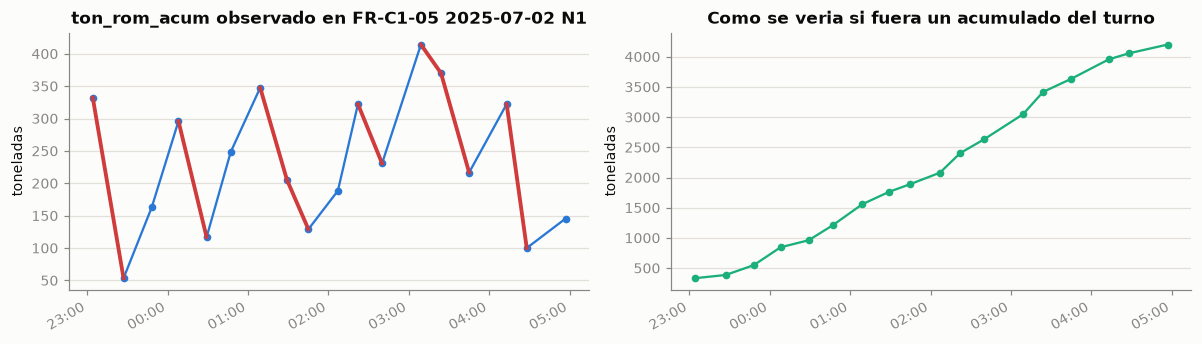

In [30]:
horas = turno["ts_opus_utc"]
valores = turno["ton_rom_acum"].values

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharex=True)

axes[0].plot(horas, valores, color=SERIES[0], linewidth=1.5, marker="o", markersize=4)
for x0, x1, y0, y1 in zip(horas[:-1], horas[1:], valores[:-1], valores[1:]):
    if y1 < y0:
        axes[0].plot([x0, x1], [y0, y1], color=CRITICAL, linewidth=2.5)
axes[0].set_title(f"ton_rom_acum observado en {clave[0]} {clave[1]} {clave[2]}")
axes[0].set_ylabel("toneladas")
axes[0].grid(axis="y")
axes[0].set_axisbelow(True)

axes[1].plot(horas, valores.cumsum(), color=SERIES[2], linewidth=1.5, marker="o", markersize=4)
axes[1].set_title("Como se veria si fuera un acumulado del turno")
axes[1].set_ylabel("toneladas")
axes[1].grid(axis="y")
axes[1].set_axisbelow(True)

for ax in axes:
    ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Aislando un turno se ve sin ambiguedad: en las dieciocho perforaciones del turno N1 del
2025-07-02 en FR-C1-05 el valor **baja en 8 de las 17 transiciones**, empieza en 332 t, sube a
414 t y termina en 146 t. Un contador acumulado no puede decrecer. Lo mismo a escala del
extracto completo: solo el 4% de los grupos frente-fecha-turno es creciente, y ese 4% es lo
que se espera por azar en grupos cortos.

El campo **no es un contador acumulado** pese a su nombre: es el tonelaje del evento
individual, entre 25 y 420 toneladas con media de 230. El panel derecho muestra como se veria
el mismo turno si de verdad acumulara. La consecuencia practica es que el tonelaje de un turno
se obtiene **sumando** los registros, no tomando el maximo: en este turno son 4201 t contra
las 414 t que daria leer el maximo como si fuera el acumulado final. El supuesto queda
declarado en lugar de heredado del nombre de la columna.

## 9. `prod_estimada_oz` — produccion estimada

El enunciado ya lo advierte entre parentesis: "calculada, no medida directamente". El dato
permite recuperar la formula exacta.

count    47190.000
mean        48.373
std         38.430
min          0.241
25%         20.151
50%         40.050
75%         69.086
max        265.496


/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:87: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(serie.dropna(), **BOX_STYLE)
/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


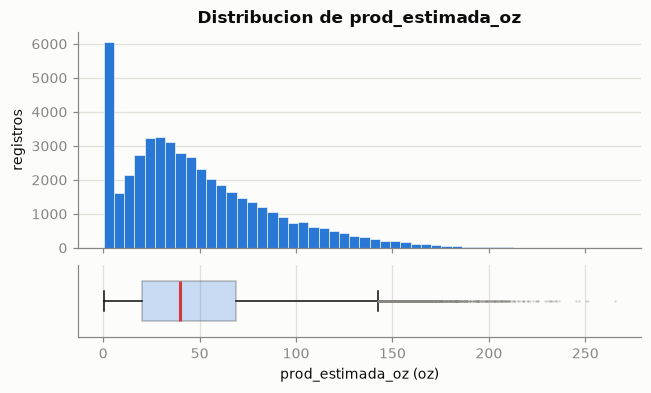

In [31]:
print(df["prod_estimada_oz"].describe().round(3).to_string())
hist_box(df["prod_estimada_oz"], "Distribucion de prod_estimada_oz", "prod_estimada_oz (oz)")

In [32]:
OZ_TROY_G = 31.1035
valida["ratio"] = valida["prod_estimada_oz"] / (valida["ley_au_gpT"] * valida["ton_rom_acum"] / OZ_TROY_G)
pd.crosstab(valida["tipo_mineral"], valida["ratio"].round(2)).replace(0, "")

ratio,0.10,0.83,0.87,0.91
tipo_mineral,,,,
EST,6730,,,
MIX,,13484,,
OX,,,13538,
SUL,,,,13438


In [33]:
RECUPERACION = {"OX": 0.87, "SUL": 0.91, "MIX": 0.83, "EST": 0.10}
reconstruida = (valida["ley_au_gpT"] * valida["ton_rom_acum"] / OZ_TROY_G
                * valida["tipo_mineral"].map(RECUPERACION))
residuo = reconstruida - valida["prod_estimada_oz"]
ss_res = float((residuo ** 2).sum())
ss_tot = float(((valida["prod_estimada_oz"] - valida["prod_estimada_oz"].mean()) ** 2).sum())

print("prod_estimada_oz = ley_au_gpT * ton_rom_acum / 31.1035 * recuperacion(tipo_mineral)")
print(f"  R2                 : {1 - ss_res / ss_tot:.12f}")
print(f"  error absoluto max : {residuo.abs().max():.2e} oz")
print()
print("nula exactamente donde la ley es centinela:",
      bool((df['prod_estimada_oz'].isna() == df['ley_sentinela']).all()))

prod_estimada_oz = ley_au_gpT * ton_rom_acum / 31.1035 * recuperacion(tipo_mineral)
  R2                 : 0.999999999972
  error absoluto max : 6.45e-04 oz

nula exactamente donde la ley es centinela: True


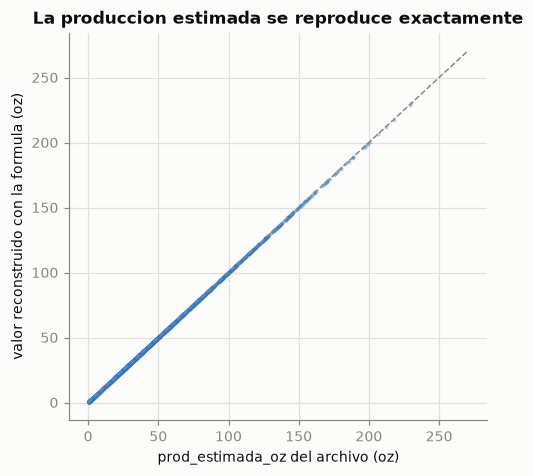

In [34]:
muestra = valida.sample(3000, random_state=7)
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(muestra["prod_estimada_oz"], reconstruida.loc[muestra.index],
           s=6, color=SERIES[0], alpha=0.35, linewidths=0)
limite = float(valida["prod_estimada_oz"].max()) * 1.02
ax.plot([0, limite], [0, limite], color=MUTED, linewidth=1, linestyle="--")
ax.set_xlabel("prod_estimada_oz del archivo (oz)")
ax.set_ylabel("valor reconstruido con la formula (oz)")
ax.set_title("La produccion estimada se reproduce exactamente")
ax.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

La reconstruccion es exacta: `prod_estimada_oz = ley_au_gpT * ton_rom_acum / 31.1035 *
recuperacion(tipo_mineral)`, con R2 de 0.999999999972 y error maximo de 6.5e-4 oz, atribuible
al redondeo del archivo a cuatro decimales. Los factores de recuperacion metalurgica que
aparecen son OX 0.87, SUL 0.91, MIX 0.83 y EST 0.10, coherentes con el dominio: el esteril
recupera diez veces menos que el mineral.

No es entonces una variable independiente sino la propia ley multiplicada por el tonelaje y por
un factor que solo depende del tipo de mineral; despejando, `ley = prod_estimada_oz * 31.1035 /
(ton_rom_acum * recuperacion)`. La direccion de la dependencia la muestra la seccion 1: la
produccion es nula exactamente en los 2810 registros donde la ley es centinela, sin una sola
excepcion. La columna no acompana a la ley, se deriva de ella.

## 10. `pres_hidraul_bar` — presion hidraulica

Rango normal publicado en el diccionario: 180 a 240 bar.

count    50000.00
mean       209.98
std         18.02
min        140.00
25%        197.90
50%        210.00
75%        222.10
max        270.00

correlacion con ley_au_gpT: +0.0033
fuera de limite           : 4748 registros (9.50%)
tasa de falla fuera       : 4.32%
tasa de falla dentro      : 3.21%


/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:87: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(serie.dropna(), **BOX_STYLE)
/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


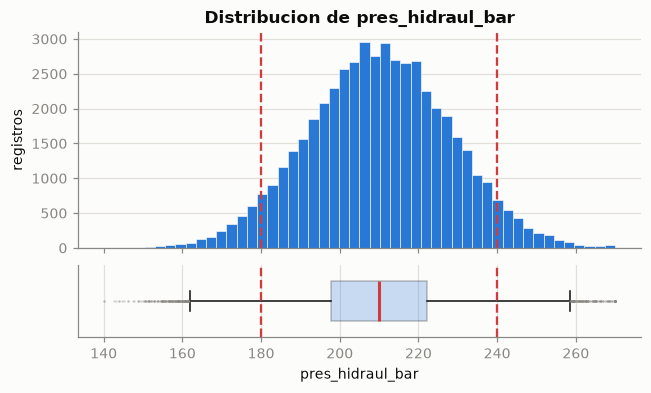

In [35]:
perfil_sensor("pres_hidraul_bar", lo=180, hi=240)

La presion sale de su banda en el 9.5% de los registros, por ambos extremos (140 a 270 bar
observados). Es la excedencia mas frecuente del extracto, pero la que menos discrimina: la tasa
de falla fuera de banda es 4.3% contra 3.3% de base.

## 11. `rpm_corona` — revoluciones de la corona

Rango operacional publicado: 800 a 1400 rpm.

count    50000.00
mean      1099.81
std        161.02
min        820.00
25%        960.00
50%       1101.00
75%       1238.00
max       1379.00

correlacion con ley_au_gpT: -0.0060
fuera de limite           : 0 registros (0.00%)
tasa de falla fuera       : sin registros fuera de limite
tasa de falla dentro      : 3.32%


/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:87: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(serie.dropna(), **BOX_STYLE)
/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


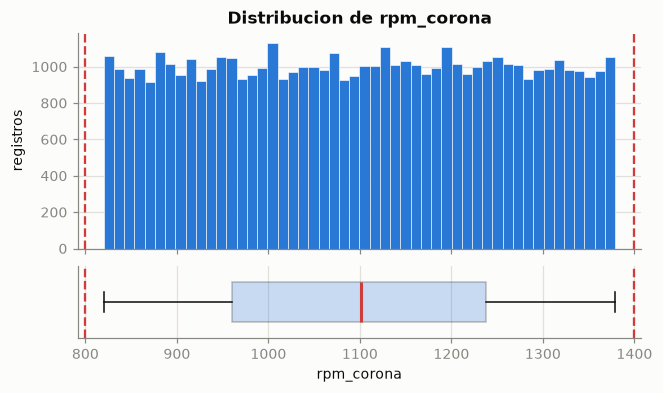

In [36]:
perfil_sensor("rpm_corona", lo=800, hi=1400)

Ningun registro sale del rango: el observado es 820 a 1379 rpm. El limite parece impuesto por el
propio equipo, de modo que una bandera de excedencia sobre esta variable no separaria ningun
subconjunto del dato.

## 12. `avance_mmin` — velocidad de avance

Metros por minuto de perforacion. El diccionario no publica un rango operacional para esta
variable, asi que solo cabe describir su distribucion.

count    50000.00
mean         1.80
std          0.40
min          0.30
25%          1.53
50%          1.80
75%          2.07
max          3.42

correlacion con ley_au_gpT: -0.0026


/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:87: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(serie.dropna(), **BOX_STYLE)
/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


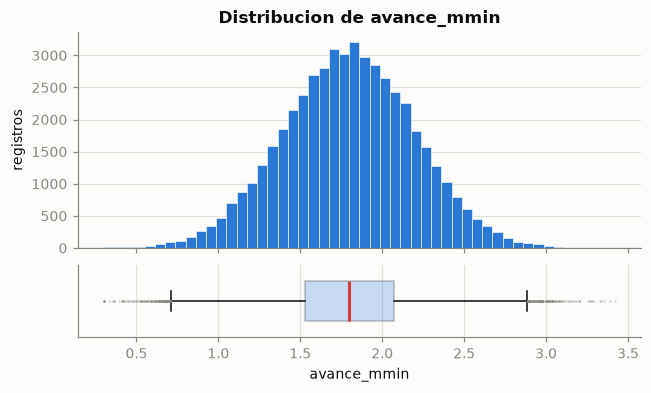

In [37]:
perfil_sensor("avance_mmin")

Distribucion simetrica alrededor de 1.8 m/min, entre 0.3 y 3.4, sin cola larga ni valores
imposibles. No correlaciona con la ley.

## 13. `agua_iny_lmin` — agua de inyeccion

Litros por minuto. Tampoco tiene rango publicado en el diccionario.

count    50000.00
mean        45.06
std         12.00
min          8.00
25%         36.96
50%         44.98
75%         53.18
max         90.00

correlacion con ley_au_gpT: -0.0048


/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:87: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(serie.dropna(), **BOX_STYLE)
/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


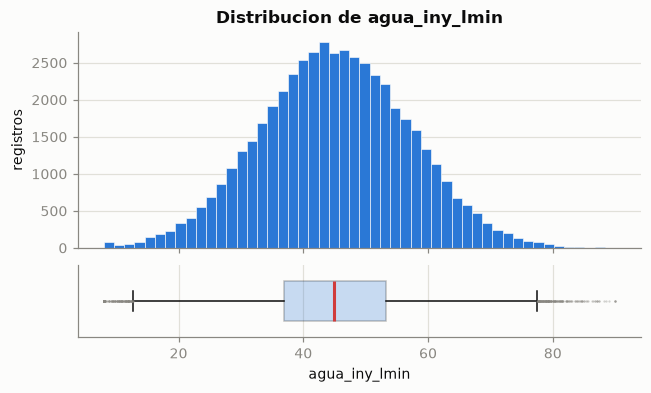

In [38]:
perfil_sensor("agua_iny_lmin")

Simetrica alrededor de 45 l/min, entre 8 y 90, sin anomalias de forma. No correlaciona con la
ley.

## 14. `vibracion_rms_ms2` — vibracion RMS

El diccionario fija 12 m/s2 como umbral de alerta operacional.

count    50000.00
mean         3.59
std          2.06
min          0.50
25%          2.07
50%          3.20
75%          4.71
max         19.62

correlacion con ley_au_gpT: +0.0044
fuera de limite           : 140 registros (0.28%)
tasa de falla fuera       : 17.14%
tasa de falla dentro      : 3.28%


/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:87: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(serie.dropna(), **BOX_STYLE)
/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


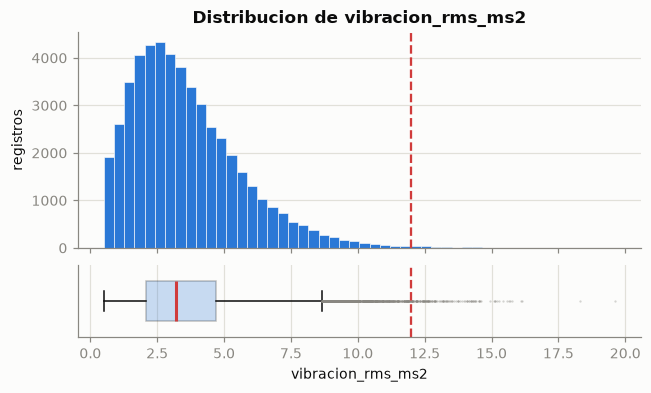

In [39]:
perfil_sensor("vibracion_rms_ms2", hi=12)

Distribucion asimetrica con cola a la derecha hasta 19.6 m/s2. Solo 140 registros (0.28%) pasan
el umbral de alerta, pero ahi la tasa de falla es del 17.1%, cinco veces la base. Es un evento
raro y muy informativo.

## 15. `temp_motor_c` — temperatura de motor

El diccionario fija 95 C como umbral de apagado automatico.

count    50000.00
mean        71.94
std         10.95
min         38.00
25%         64.50
50%         72.00
75%         79.40
max        108.49

correlacion con ley_au_gpT: -0.0048
fuera de limite           : 922 registros (1.84%)
tasa de falla fuera       : 22.02%
tasa de falla dentro      : 2.97%


/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:87: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(serie.dropna(), **BOX_STYLE)
/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


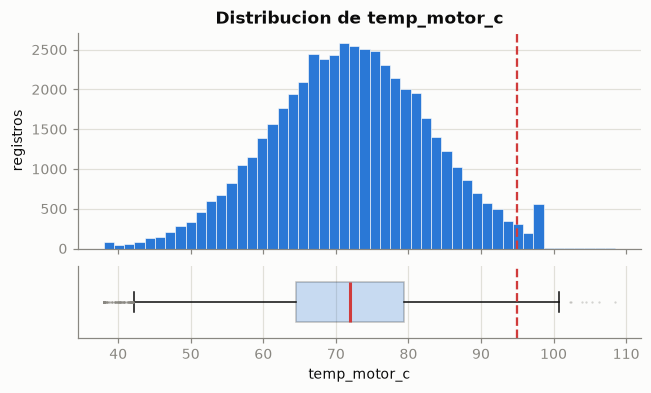

In [40]:
perfil_sensor("temp_motor_c", hi=95)

922 registros (1.8%) superan el umbral de apagado y ahi la tasa de falla es del 22.0%, casi
siete veces la base. Es el precursor mas fuerte del extracto; la comparacion de distribuciones
con y sin falla esta en la seccion 16.

## 16. `falla_cod` — codigo de falla

Nulo significa operacion normal, de modo que la columna define implicitamente el evento de
falla. El prefijo del codigo identifica el subsistema.

In [41]:
df["falla"] = df["falla_cod"].notna()
print(f"prevalencia global: {df['falla'].mean() * 100:.2f}%  ({int(df['falla'].sum())} de {len(df):,})")
print()
codigos = df["falla_cod"].value_counts().rename_axis("codigo").to_frame("eventos")
codigos["subsistema"] = codigos.index.str.split("-").str[1]
print(codigos.to_string())

prevalencia global: 3.32%  (1659 de 50,000)

            eventos subsistema
codigo                        
E-ELEC-01       227       ELEC
M-MOTOR-07      219      MOTOR
H-HIDRA-02      210      HIDRA
B-BOMBA-01      209      BOMBA
H-HIDRA-05      202      HIDRA
M-MOTOR-03      202      MOTOR
S-SELLO-02      198      SELLO
E-ELEC-04       192       ELEC


/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/1131910317.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot([df.loc[~df["falla"], "temp_motor_c"], df.loc[df["falla"], "temp_motor_c"]],


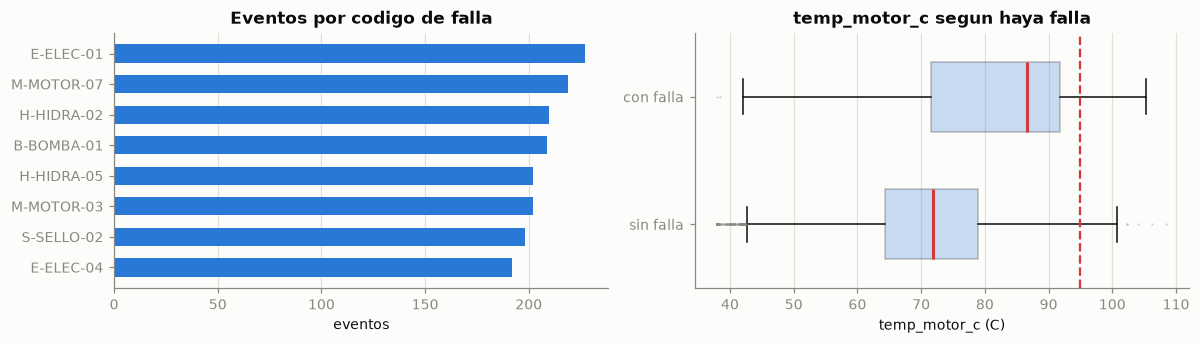

In [42]:
codigos = df["falla_cod"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].barh(codigos.index[::-1], codigos.values[::-1], color=SERIES[0], height=0.6)
axes[0].set_title("Eventos por codigo de falla")
axes[0].set_xlabel("eventos")
axes[0].grid(axis="x")
axes[0].set_axisbelow(True)

axes[1].boxplot([df.loc[~df["falla"], "temp_motor_c"], df.loc[df["falla"], "temp_motor_c"]],
                tick_labels=["sin falla", "con falla"], **BOX_STYLE)
axes[1].axvline(95, color=CRITICAL, linewidth=1.5, linestyle="--")
axes[1].set_title("temp_motor_c segun haya falla")
axes[1].set_xlabel("temp_motor_c (C)")
axes[1].grid(axis="x")
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

In [43]:
comparacion_falla = (df.groupby("falla")[["temp_motor_c", "vibracion_rms_ms2", "pres_hidraul_bar",
                                          "rpm_corona", "avance_mmin", "agua_iny_lmin"]]
                       .mean().T)
comparacion_falla.columns = ["sin falla", "con falla"]
comparacion_falla["delta"] = comparacion_falla["con falla"] - comparacion_falla["sin falla"]
comparacion_falla.round(2)

,sin falla,con falla,delta
temp_motor_c,71.61,81.38,9.76
vibracion_rms_ms2,3.59,3.72,0.13
pres_hidraul_bar,210.01,209.13,-0.88
rpm_corona,1099.78,1100.65,0.86
avance_mmin,1.80,1.79,-0.01
agua_iny_lmin,45.06,44.95,-0.11


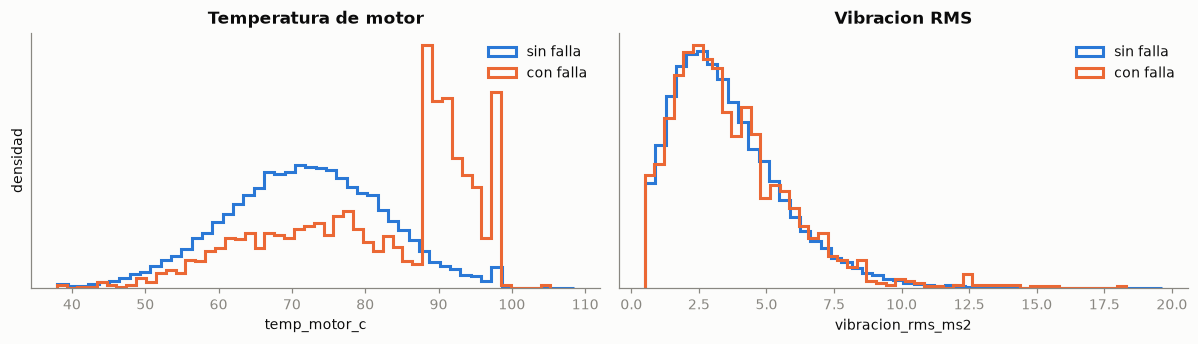

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

for ax, col, titulo in zip(axes,
                           ["temp_motor_c", "vibracion_rms_ms2"],
                           ["Temperatura de motor", "Vibracion RMS"]):
    for etiqueta, color, mascara in [("sin falla", SERIES[0], ~df["falla"]),
                                     ("con falla", SERIES[1], df["falla"])]:
        ax.hist(df.loc[mascara, col], bins=50, density=True, histtype="step",
                linewidth=2, color=color, label=etiqueta)
    ax.set_title(titulo)
    ax.set_xlabel(col)
    ax.set_yticks([])
    ax.legend()
    ax.grid(axis="y")
    ax.set_axisbelow(True)
axes[0].set_ylabel("densidad")

plt.tight_layout()
plt.show()

In [45]:
condiciones = {
    "temp_motor_c > 95": df["temp_motor_c"] > 95,
    "vibracion_rms_ms2 > 12": df["vibracion_rms_ms2"] > 12,
    "presion fuera de 180-240": ~df["pres_hidraul_bar"].between(180, 240),
    "flag_mant_prev = 1": df["flag_mant_prev"].eq(1),
    "linea base (todos)": pd.Series(True, index=df.index),
}
pd.DataFrame([
    {"condicion": nombre,
     "registros": int(mascara.sum()),
     "tasa_falla_pct": round(df.loc[mascara, "falla"].mean() * 100, 2)}
    for nombre, mascara in condiciones.items()
])

,condicion,registros,tasa_falla_pct
0,temp_motor_c > 95,922,22.02
1,vibracion_rms_ms2 > 12,140,17.14
2,presion fuera de 180-240,4748,4.32
3,flag_mant_prev = 1,1213,2.80
4,linea base (todos),50000,3.32


La falla es un evento raro: 3.32% de los registros, 1659 eventos repartidos en ocho codigos de
cinco subsistemas (electrico, motor, hidraulico, bomba y sello) con frecuencias muy parejas,
entre 192 y 227 eventos cada uno. Ningun subsistema domina.

La temperatura de motor es el unico precursor claro: casi diez grados de diferencia en media
(81.4 C con falla contra 71.6 C sin) y 22% de tasa de falla sobre el umbral de apagado. La
vibracion separa poco en media, aunque sus excedencias tambien multiplican por cinco la tasa.
La presion fuera de banda casi no discrimina.

## 17. `flag_mant_prev` — ventana de mantenimiento preventivo

Bandera binaria: 1 si el registro cae dentro de una ventana de mantenimiento preventivo.

registros con flag_mant_prev = 1: 1213 (2.43%)

                registros  tasa_falla_pct
flag_mant_prev                           
0                   48787            3.33
1                    1213            2.80


/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:139: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot([valida.loc[valida[col] == k, valor].dropna().values for k in orden],


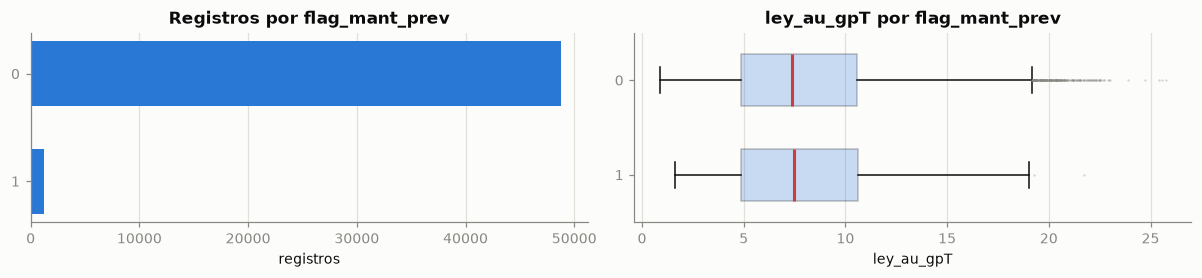

,registros,ley_media,falla_pct
flag_mant_prev,,,
0,48787,8.00,3.33
1,1213,7.97,2.80


In [46]:
print(f"registros con flag_mant_prev = 1: {int(df['flag_mant_prev'].sum())} "
      f"({df['flag_mant_prev'].mean() * 100:.2f}%)")
print()
print((df.groupby("flag_mant_prev")["falla"].agg(registros="size", tasa_falla_pct=lambda s: s.mean() * 100)
         .round(2)).to_string())
perfil_categorica("flag_mant_prev")

Solo el 2.4% de los registros cae dentro de una ventana preventiva, y ahi la tasa de falla es
2.80% contra 3.33% fuera. **El mantenimiento preventivo no reduce la tasa de falla** de forma
apreciable: si el programa funcionara, la diferencia deberia ser mucho mayor. Es un hallazgo
con lectura operacional directa y vale la pena reportarlo al area de mantenimiento.

## 18. `equipo_id` — equipo de perforacion

Diez equipos de tres fabricantes (ATLAS, BOAR, SAND), con unos 5000 registros cada uno.

frentes distintos por equipo: [13]


/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:139: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot([valida.loc[valida[col] == k, valor].dropna().values for k in orden],


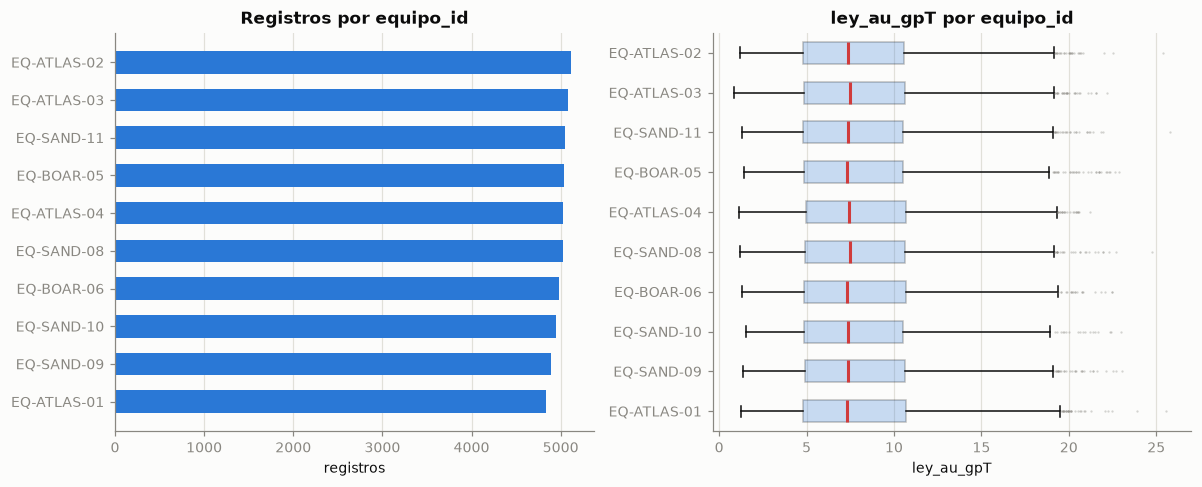

,registros,ley_media,falla_pct
equipo_id,,,
EQ-ATLAS-02,5115,7.94,3.44
EQ-ATLAS-03,5084,8.02,3.36
EQ-SAND-11,5045,7.95,3.37
EQ-BOAR-05,5036,7.95,3.61
EQ-ATLAS-04,5026,8.06,3.30
EQ-SAND-08,5025,8.05,3.36
EQ-BOAR-06,4984,8.01,3.15
EQ-SAND-10,4953,7.91,2.81
EQ-SAND-09,4892,8.04,3.35


In [47]:
print("frentes distintos por equipo:", df.groupby("equipo_id")["frente_id"].nunique().unique())
perfil_categorica("equipo_id")

Cada equipo trabaja en los trece frentes, asi que el equipo no esta confundido con la
ubicacion: la ley media por equipo es plana (7.91 a 8.06 g/t). Las fallas tambien se reparten
de forma casi uniforme, entre 2.81% y 3.61%.

Leido bajo el supuesto adoptado en la seccion 2, esto no es un hallazgo operacional sino su
consecuencia: `equipo_id` es una etiqueta repartida al azar sobre un flujo serial, no un activo
fisico con historia propia. La lectura correcta no es "no hay un equipo problematico" sino
**la columna no permite decir nada sobre los equipos**, ni a favor ni en contra.

## 19. `op_id` — operador

Dieciocho operadores identificados con un hash corto, unos 2780 registros cada uno.

equipos distintos por operador: [10]


/var/folders/3j/6fzlb8zs67dddw5b9n47v1gh0000gn/T/ipykernel_44672/650213047.py:139: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot([valida.loc[valida[col] == k, valor].dropna().values for k in orden],


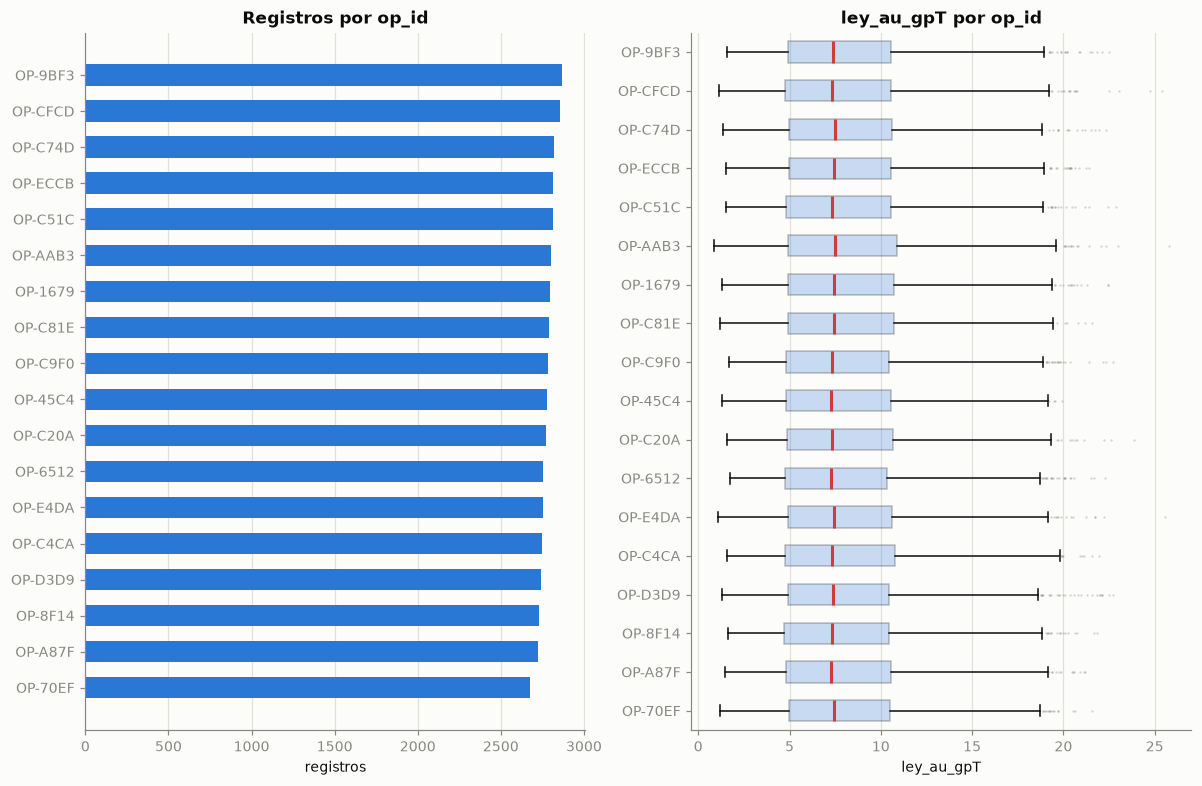

,registros,ley_media,falla_pct
op_id,,,
OP-9BF3,2865,8.01,3.04
OP-CFCD,2858,7.98,3.22
OP-C74D,2817,8.09,3.16
OP-ECCB,2816,8.02,3.59
OP-C51C,2813,7.98,3.34
OP-AAB3,2800,8.15,3.21
OP-1679,2795,8.01,3.65
OP-C81E,2788,8.04,3.26
OP-C9F0,2781,7.99,3.70


In [48]:
print("equipos distintos por operador:", df.groupby("op_id")["equipo_id"].nunique().unique())
perfil_categorica("op_id")

Cada operador pasa por los diez equipos, de modo que tampoco esta confundido con el activo. La
ley media por operador es plana (7.90 a 8.15 g/t) y la tasa de falla varia entre 2.46% y 3.89%,
un rango compatible con el azar para menos de 3000 registros por operador.

Vale la misma lectura que para `equipo_id`: bajo el supuesto de la seccion 2, `op_id` es una
etiqueta sin contenido y no soporta ninguna afirmacion sobre el desempeno de las cuadrillas.
Que la ley no dependa del operador es ademas lo unico que cabria esperar: el operador no cambia
la geologia.

## 20. Sintesis

| Variable | Hallazgo | Evidencia |
|---|---|---|
| `ts_opus_utc` | el extracto cubre 27.9 meses, no los 18 del enunciado | 2023-07-01 a 2025-10-28 |
| `ts_opus_utc` | flujo estrictamente serial: se adopta el supuesto de extracto sintetico | cadencia uniforme de 15 a 34 min, cero eventos simultaneos |
| `turno_cod` | es funcion determinista de la hora, con desfase UTC-5 | cada hora UTC cae en un unico turno |
| `frente_id` | es la variable que mas separa la ley | medias de 2.9 a 15.3 g/t |
| `sector_geol` | misma jerarquia que el frente, mas gruesa | cada frente pertenece a un unico sector |
| `tipo_mineral` | no discrimina la ley; determina la recuperacion | rango de medias de 0.06 g/t |
| `ley_au_gpT` | usa `-1.0` como centinela de "sin lectura" | unico valor negativo, 2810 registros (5.6%) |
| `ley_au_gpT` | el faltante no es aleatorio | 16.1% en N2 contra ~2.1% en el resto |
| `ton_rom_acum` | no es un acumulado pese a su nombre | creciente en 4.0% de los grupos |
| `prod_estimada_oz` | es funcion determinista de la ley | R2 = 0.999999999972; nula donde la ley es centinela |
| `pres_hidraul_bar` | excedencia frecuente y poco informativa | 9.5% fuera de banda, 4.3% de falla contra 3.3% base |
| `rpm_corona` | nunca sale de su rango | 0 registros fuera de 800-1400 |
| `avance_mmin`, `agua_iny_lmin` | distribuciones limpias, sin relacion con la ley | correlaciones por debajo de 0.01 |
| `vibracion_rms_ms2` | excedencia rara y muy informativa | 0.28% sobre 12 m/s2, con 17.1% de falla |
| `temp_motor_c` | precursor mas fuerte de la falla | 22.0% de falla sobre 95 C contra 3.3% base |
| `falla_cod` | evento raro y repartido entre subsistemas | 3.32%, ocho codigos de 192 a 227 eventos |
| `flag_mant_prev` | el preventivo no reduce fallas | 2.80% dentro de la ventana contra 3.33% fuera |
| `equipo_id` | etiqueta sin contenido: no admite lectura causal | ley y falla planas entre equipos; cada equipo en los 13 frentes |
| `op_id` | etiqueta sin contenido: no admite lectura causal | ley plana entre operadores; cada operador en los 10 equipos |